***ACO FOR TASK SCHEDULING***

---



# Foundations

**import Libraries**

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt


Generates Data

In [ ]:
def generate_instance(total_tasks, total_machines):
    """
    Generates a single instance of task scheduling data.
    """
    # Generate task IDs
    tasks = list(range(1, total_tasks + 1))

    # Generate machine IDs
    machines = list(range(1, total_machines + 1))

    # Generate time matrix (random processing times)
    time_matrix = [[random.randint(5, 10) for _ in range(total_machines)] for _ in range(total_tasks)]

    return tasks, machines, time_matrix

def save_instances_to_file(filename, instances):
    """
    Saves multiple instances to a file, separated by a delimiter.
    """
    with open(filename, 'w') as file:
        for idx, instance in enumerate(instances):
            tasks, machines, time_matrix = instance

            # Write task IDs
            file.write(" ".join(map(str, tasks)) + "\n")

            # Write machine IDs
            file.write(" ".join(map(str, machines)) + "\n")

            # Write time matrix
            for row in time_matrix:
                file.write(" ".join(map(str, row)) + "\n")

            # Add delimiter between instances (except after the last instance)
            if idx < len(instances) - 1:
                file.write("---\n")

def generate_and_save_instances(filename, num_instances, initial_tasks, task_increment, total_machines):
    """
    Generates and saves multiple instances to a file.
    The number of tasks starts at `initial_tasks` and increments by `task_increment` for each instance.
    """
    instances = []
    for i in range(num_instances):
        # Calculate the number of tasks for this instance
        total_tasks = initial_tasks + i * task_increment

        # Generate the instance
        instance = generate_instance(total_tasks, total_machines)
        instances.append(instance)

    # Save all instances to the file
    save_instances_to_file(filename, instances)
    print(f"Generated {num_instances} instances and saved to {filename}.")

# Example usage
filename = "instances.txt"  # Output file name
num_instances = 10  # Number of instances to generate
initial_tasks = 10  # Starting number of tasks
task_increment = 10  # Increment tasks by this value for each instance
total_machines = 10  # Fixed number of machines per instance

generate_and_save_instances(filename, num_instances, initial_tasks, task_increment, total_machines)

Generated 10 instances and saved to instances.txt.


Load data

In [ ]:
# Function to load multiple instances from a single file
def load_instances_from_file(filename):
    """
    Loads multiple instances from a single file.
    Each instance is separated by a delimiter (e.g., '---').
    """
    instances = []
    with open(filename, 'r') as file:
        content = file.read().strip().split('---')  # Split instances by delimiter
        for instance_data in content:
            lines = instance_data.strip().split('\n')
            if len(lines) < 3:  # Skip empty or invalid instances
                continue

            # Parse tasks: Split based on spaces
            tasks = list(map(int, lines[0].strip().split()))

            # Parse machines: Split based on spaces
            machines = list(map(int, lines[1].strip().split()))

            # Parse time matrix
            time_matrix = [list(map(int, line.strip().split())) for line in lines[2:]]

            # Verify dimensions
            assert len(time_matrix) == len(tasks), \
                f"Expected {len(tasks)} rows in time_matrix, but got {len(time_matrix)}."
            for row in time_matrix:
                assert len(row) == len(machines), \
                    f"Expected {len(machines)} columns in time_matrix row, but got {len(row)}."

            # Store the instance
            instances.append({
                "tasks": tasks,
                "machines": machines,
                "time_matrix": time_matrix
            })

    return instances

Initialization

In [ ]:
# Function to initialize pheromone matrix
def initialize_pheromones(tasks, vms):
    return np.ones((len(tasks), len(vms)))  # Initialize pheromone matrix with 1s

# ACO Parameters
n_ants = 10  # Number of ants (solutions)
n_iterations = 100  # Number of iterations
alpha = 1  # Influence of pheromone
beta = 2  # Influence of heuristic (task time)
gamma = 2  # Influence of load balance (new parameter)
rho = 0.1  # Pheromone evaporation rate
Q = 100  # Total pheromone to deposit

# MMAS Parameters
tau_min = 0.1  # Minimum pheromone value
tau_max = 10.0  # Maximum pheromone value


visualization

In [ ]:
# Function to plot results for multiple instances
def plot_instance_results(results):
    """
    Plots the results for multiple instances:
    1. Grouped bar plot for Best, Average, and Worst Makespan.
    2. Line plot for Solution Quality (makespan over iterations).
    3. Bar plot for Unbalanced Factor.
    4. Line plot for Solution Quality (makespan over iterations) for each instance.
    5. Line plot for Unbalanced Factor over iterations.
    """
    instance_names = [result['instance'] for result in results]
    best_makespans = [result['best_makespan'] for result in results]
    average_makespans = [result['average_makespan'] for result in results]
    worst_makespans = [result['worst_makespan'] for result in results]
    unbalanced_factors = [result['unbalanced_factor'] for result in results]
    solution_qualities = [result['solution_quality'] for result in results]


    plt.figure(figsize=(15, 5))

    # Plot 1: Best, Average, and Worst Makespan
    plt.subplot(1, 3, 1)
    plt.plot(instance_names, best_makespans, label="Best Makespan", marker="o", color="green")
    plt.plot(instance_names, average_makespans, label="Average Makespan", marker="x", color="blue")
    plt.plot(instance_names, worst_makespans, label="Worst Makespan", marker="s", color="red")
    plt.xlabel("Instance")
    plt.ylabel("Makespan")
    plt.title("Best, Average, and Worst Makespan")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    # Plot 2: Solution Quality (Makespan over iterations)
    plt.subplot(1, 3, 2)
    for i, solution_quality in enumerate(solution_qualities):
        plt.plot(range(1, len(solution_quality) + 1), solution_quality, label=f"Instance {i + 1}")
    plt.xlabel("Iterations")
    plt.ylabel("Makespan")
    plt.title("Solution Quality Over Iterations")
    plt.legend()
    plt.grid(True)

    # Plot 3: Unbalanced Factor
    plt.subplot(1, 3, 3)
    plt.plot(instance_names, unbalanced_factors, label="Unbalanced Factor", marker="o", color="purple")
    plt.xlabel("Instance")
    plt.ylabel("Unbalanced Factor")
    plt.title("Unbalanced Factor Across Instances")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(15, 5))

    # Plot 1: Grouped bar plot for Best, Average, and Worst Makespan

    x = np.arange(len(instance_names))  # the label locations
    width = 0.2  # the width of the bars
    plt.subplot(1, 3, 1)
    plt.bar(x - width, best_makespans, width, label='Best Makespan', color='green')
    plt.bar(x, average_makespans, width, label='Average Makespan', color='blue')
    plt.bar(x + width, worst_makespans, width, label='Worst Makespan', color='red')

    plt.xlabel('Instance')
    plt.ylabel('Makespan')
    plt.title('Best, Average, and Worst Makespan for Each Instance')
    plt.xticks(x, instance_names, rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()


    # Plot 2: Bar plot for Unbalanced Factor
    plt.subplot(1, 2, 2)
    plt.bar(instance_names, unbalanced_factors, color='purple')
    plt.xlabel('Instance')
    plt.ylabel('Degree of Imbalance (DI)')
    plt.title('Degree of Imbalance for Each Instance')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()


    plt.show()




Evaluate instances using AS, ACO, MMAS methods

In [ ]:
# Function to evaluate
def evaluate_instances_from_file(system_name, filename):
    """
     multiple instances
    """
    instances = load_instances_from_file(filename)
    results = []

    for idx, instance in enumerate(instances):
        print(f"Evaluating Instance {idx + 1}")
        tasks = instance['tasks']
        machines = instance['machines']
        time_matrix = np.array(instance['time_matrix'])

        # Initialize pheromones and heuristic matrix
        pheromone_matrix = initialize_pheromones(tasks, machines)
        heuristic_matrix = 1 / (time_matrix + 1e-10)

        # Run ACO for the current instance
        if system_name == "AS":
            best_solution, best_makespan, solution_quality, uf = as_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)
        elif system_name == "ACS":
            best_solution, best_makespan, solution_quality, uf = acs_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)
        elif system_name == "MMAS":
            best_solution, best_makespan, solution_quality, uf = mmas_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)
        elif system_name == "OMMAS":
            best_solution, best_makespan, solution_quality, uf = ommas_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)
        elif system_name == "OAS":
            best_solution, best_makespan, solution_quality, uf = oas_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)
        elif system_name == "OACS":
            best_solution, best_makespan, solution_quality, uf = oacs_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)
        else:
            raise ValueError("Invalid system name. Choose 'AS', 'ACO', or 'MMAS'.")

        # Calculate average and worst makespan
        average_makespan = np.mean(solution_quality)
        worst_makespan = np.max(solution_quality)

        # Store results for this instance
        results.append({
            "instance": f"Instance {idx + 1}",
            "best_makespan": best_makespan,
            "average_makespan": average_makespan,
            "worst_makespan": worst_makespan,
            "solution_quality": solution_quality,
            "unbalanced_factor": np.mean(uf)  # Use the mean unbalanced factor
        })

        print(f"Instance {idx + 1}: Best Makespan = {best_makespan}, Average Makespan = {average_makespan:.2f}, Worst Makespan = {worst_makespan}, Unbalanced Factor = {np.mean(uf):.4f}")

    return results


**AS**

# Original


This section contains an evaluation of the performance of the regular (original) ant colony algorithm in the task scheduling problem.

AS

In [ ]:
import random
import numpy as np

def oas_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):

                    # Calculate the pheromone and probability
                    pheromone = pheromone_matrix[task - 1, vm_idx] ** alpha
                    heuristic = 1 / time_matrix[task - 1, vm_idx]  # Inverse of processing time
                    probability = pheromone * (heuristic ** beta)
                    probabilities.append(probability)

                # Normalize probabilities
                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                # Roulette Wheel Selection
                cumulative_probabilities = [sum(probabilities[:i+1]) for i in range(len(probabilities))]
                random_value = random.random()
                chosen_vm_idx = next(vm_idx for vm_idx, cumulative in enumerate(cumulative_probabilities) if random_value <= cumulative)
                chosen_vm = vms[chosen_vm_idx]

                # Update VM loads and solution
                task_time = time_matrix[task - 1, chosen_vm_idx]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Pheromone update
        pheromone_matrix *= (1 - rho)
        for i, solution in enumerate(all_solutions):
            pheromone_deposit = Q / all_makespans[i]
            for task, vm in solution:
                pheromone_matrix[task - 1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors


Evaluating Instance 1
Instance 1: Best Makespan = 6, Average Makespan = 7.74, Worst Makespan = 12, Unbalanced Factor = 1.9681
Evaluating Instance 2
Instance 2: Best Makespan = 15, Average Makespan = 15.47, Worst Makespan = 24, Unbalanced Factor = 1.7656
Evaluating Instance 3
Instance 3: Best Makespan = 20, Average Makespan = 21.01, Worst Makespan = 31, Unbalanced Factor = 1.7453
Evaluating Instance 4
Instance 4: Best Makespan = 26, Average Makespan = 27.66, Worst Makespan = 38, Unbalanced Factor = 1.7567
Evaluating Instance 5
Instance 5: Best Makespan = 31, Average Makespan = 33.41, Worst Makespan = 57, Unbalanced Factor = 1.7251
Evaluating Instance 6
Instance 6: Best Makespan = 36, Average Makespan = 37.62, Worst Makespan = 55, Unbalanced Factor = 1.7588
Evaluating Instance 7
Instance 7: Best Makespan = 47, Average Makespan = 48.38, Worst Makespan = 64, Unbalanced Factor = 1.8482
Evaluating Instance 8
Instance 8: Best Makespan = 52, Average Makespan = 54.32, Worst Makespan = 75, Unbal

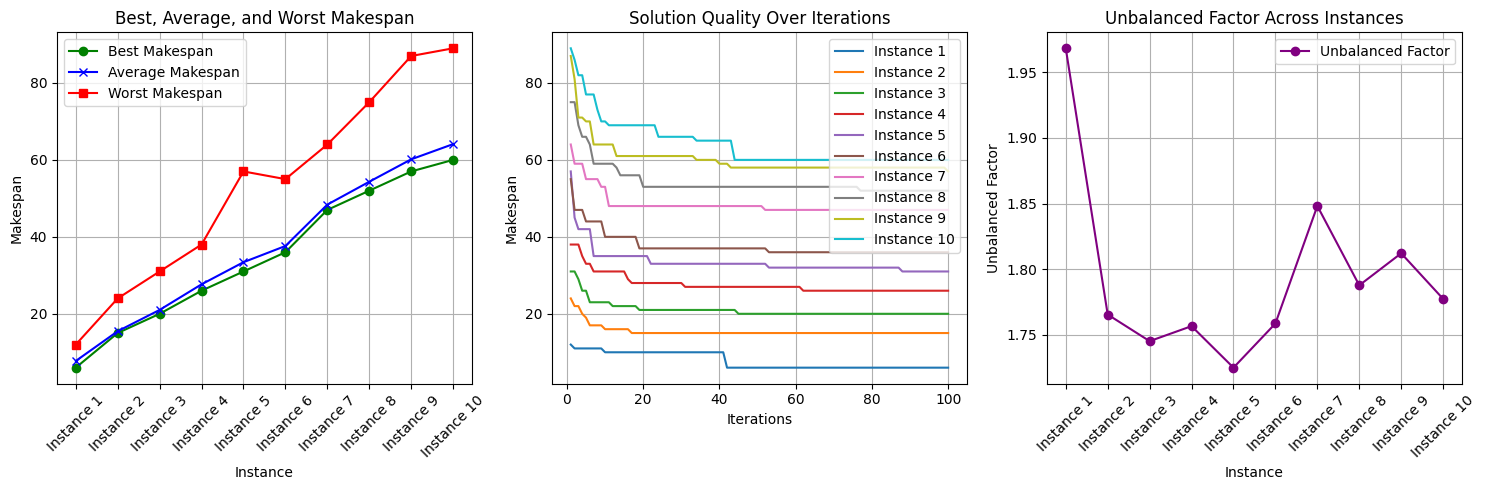

<ipython-input-16-44398d8565cc>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


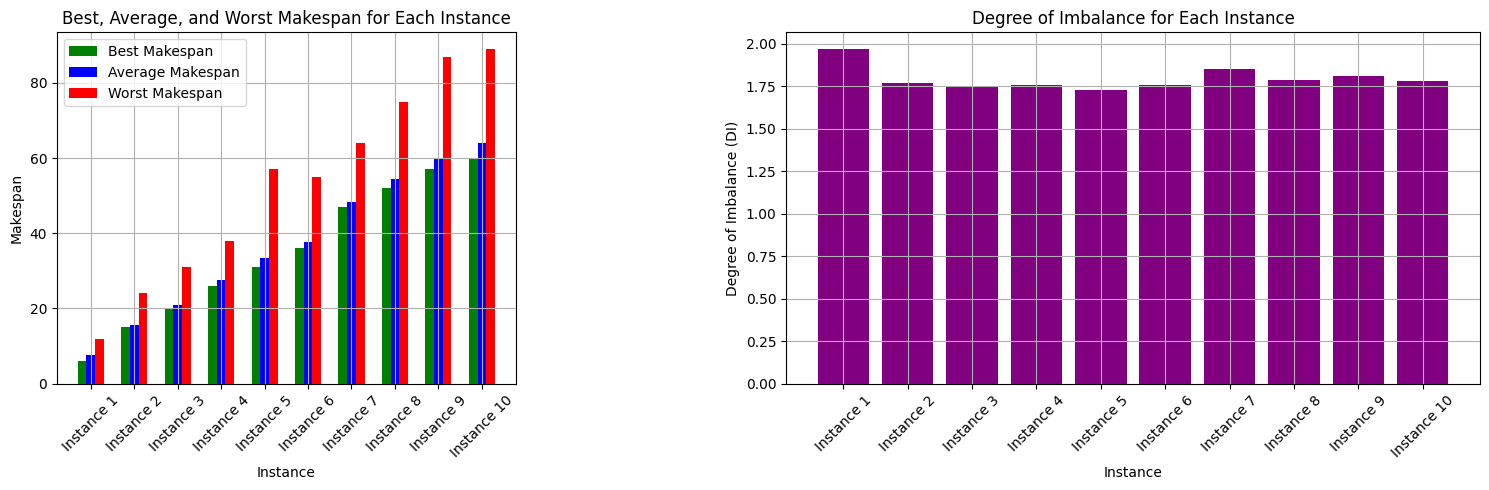

In [ ]:
filename = "instances.txt"  # File containing all instances
results = evaluate_instances_from_file("OAS", filename)
plot_instance_results(results)

---

MMAS

In [ ]:
# Function for Min-Max Ant System (MMAS)
def ommas_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):

                    # Calculate the pheromone and probability
                    pheromone = pheromone_matrix[task - 1, vm_idx] ** alpha
                    heuristic = 1 / time_matrix[task - 1, vm_idx]  # Inverse of processing time
                    probability = pheromone * (heuristic ** beta)
                    probabilities.append(probability)

                # Normalize probabilities
                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                # Roulette Wheel Selection
                cumulative_probabilities = [sum(probabilities[:i+1]) for i in range(len(probabilities))]
                random_value = random.random()
                chosen_vm_idx = next(vm_idx for vm_idx, cumulative in enumerate(cumulative_probabilities) if random_value <= cumulative)
                chosen_vm = vms[chosen_vm_idx]

                # Update VM loads and solution
                task_time = time_matrix[task - 1, chosen_vm_idx]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Pheromone update (Global Best Only)
        pheromone_matrix *= (1 - rho)
        pheromone_deposit = Q / best_makespan
        for task, vm in best_solution:
            pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Apply Min-Max limits to pheromone values
        pheromone_matrix = np.clip(pheromone_matrix, tau_min, tau_max)

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors


Evaluating Instance 1
Instance 1: Best Makespan = 10, Average Makespan = 10.43, Worst Makespan = 13, Unbalanced Factor = 0.9575
Evaluating Instance 2
Instance 2: Best Makespan = 17, Average Makespan = 17.06, Worst Makespan = 20, Unbalanced Factor = 1.0360
Evaluating Instance 3
Instance 3: Best Makespan = 22, Average Makespan = 23.93, Worst Makespan = 32, Unbalanced Factor = 0.9268
Evaluating Instance 4
Instance 4: Best Makespan = 25, Average Makespan = 26.93, Worst Makespan = 39, Unbalanced Factor = 0.5174
Evaluating Instance 5
Instance 5: Best Makespan = 35, Average Makespan = 37.00, Worst Makespan = 50, Unbalanced Factor = 0.7457
Evaluating Instance 6
Instance 6: Best Makespan = 42, Average Makespan = 43.62, Worst Makespan = 56, Unbalanced Factor = 0.4886
Evaluating Instance 7
Instance 7: Best Makespan = 45, Average Makespan = 48.23, Worst Makespan = 63, Unbalanced Factor = 0.4358
Evaluating Instance 8
Instance 8: Best Makespan = 54, Average Makespan = 56.20, Worst Makespan = 75, Unb

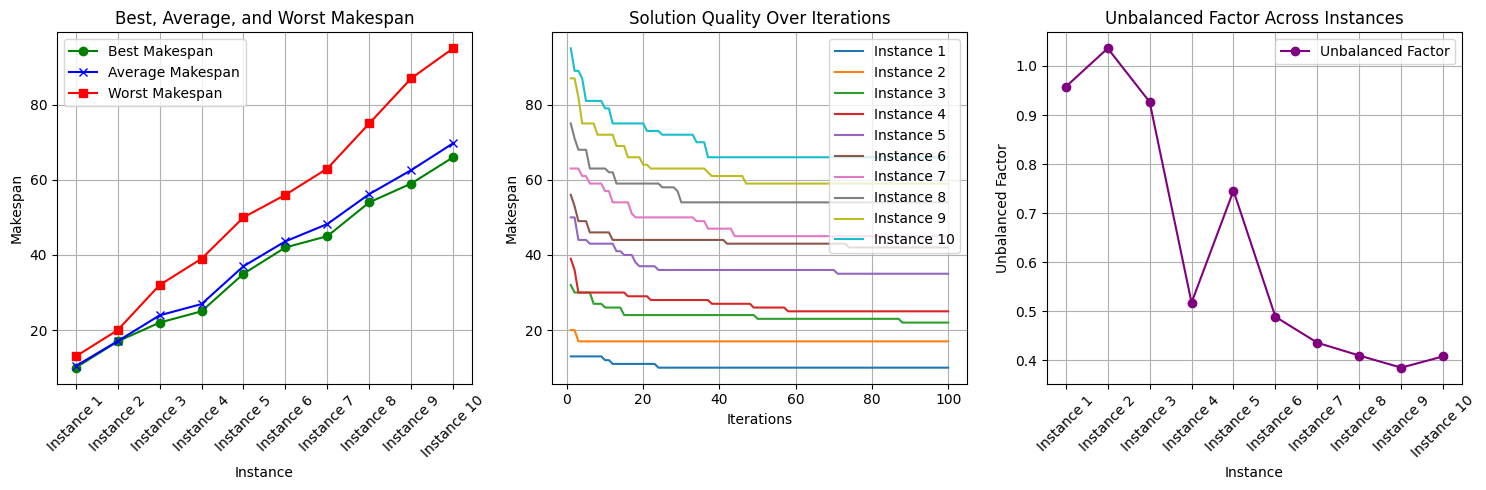

<ipython-input-5-d5b5252b6a9d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


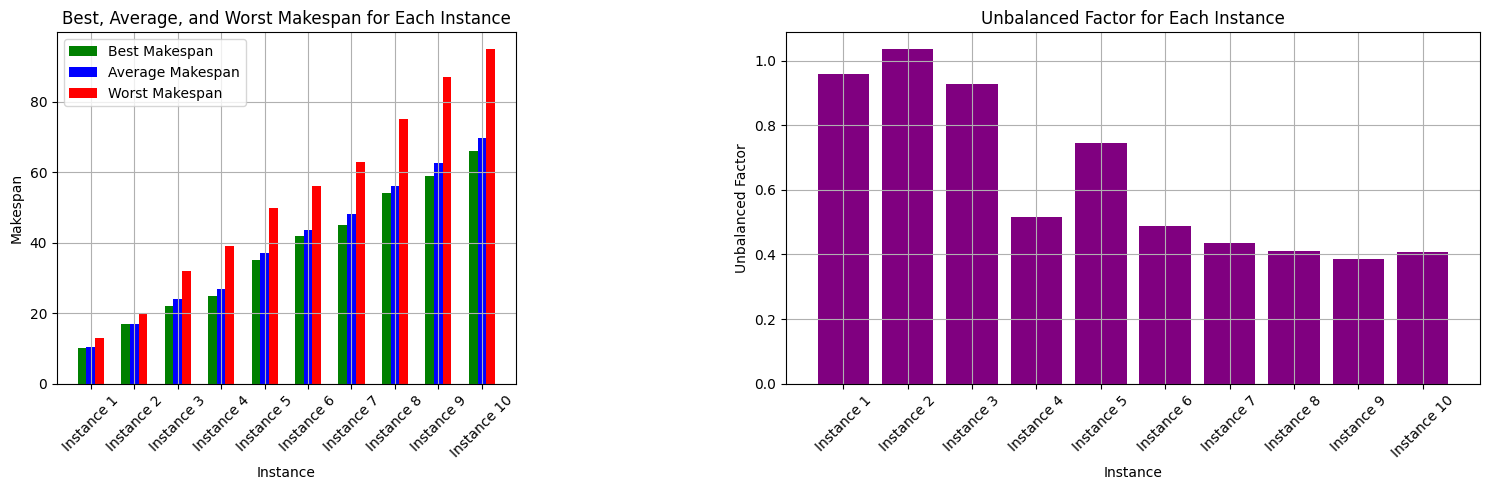

In [ ]:
filename = "instances.txt"  # File containing all instances
results = evaluate_instances_from_file("OMMAS", filename)
plot_instance_results(results)

---

ACO

In [ ]:
# Function for Ant Colony Optimization
def oacs_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):

                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = 1 / time_matrix[task - 1, vm_idx]  # Inverse of processing time
                    probability = pheromone * (heuristic ** beta)
                    probabilities.append(probability)

                # Normalize probabilities
                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                # Roulette Wheel Selection
                cumulative_probabilities = [sum(probabilities[:i+1]) for i in range(len(probabilities))]
                random_value = random.random()
                chosen_vm_idx = next(vm_idx for vm_idx, cumulative in enumerate(cumulative_probabilities) if random_value <= cumulative)
                chosen_vm = vms[chosen_vm_idx]

                # Update VM loads and solution
                task_time = time_matrix[task - 1, chosen_vm_idx]
                vm_loads[chosen_vm] += task_time


                # Local Update: Update pheromone for the chosen task-VM pair
                pheromone_matrix[task-1, vms.index(chosen_vm)] = (1 - rho) * pheromone_matrix[task-1, vms.index(chosen_vm)] + (rho * Q / task_time)

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Global Update: Only the best ant updates the pheromone matrix
        pheromone_matrix *= (1 - rho)
        for task, vm in best_solution:
            pheromone_deposit = Q / best_makespan
            pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors


Evaluating Instance 1
Instance 1: Best Makespan = 10, Average Makespan = 10.30, Worst Makespan = 13, Unbalanced Factor = 2.1124
Evaluating Instance 2
Instance 2: Best Makespan = 16, Average Makespan = 16.20, Worst Makespan = 23, Unbalanced Factor = 1.4056
Evaluating Instance 3
Instance 3: Best Makespan = 22, Average Makespan = 23.17, Worst Makespan = 24, Unbalanced Factor = 1.2134
Evaluating Instance 4
Instance 4: Best Makespan = 27, Average Makespan = 28.68, Worst Makespan = 34, Unbalanced Factor = 0.9488
Evaluating Instance 5
Instance 5: Best Makespan = 33, Average Makespan = 34.41, Worst Makespan = 46, Unbalanced Factor = 0.8826
Evaluating Instance 6
Instance 6: Best Makespan = 40, Average Makespan = 41.03, Worst Makespan = 52, Unbalanced Factor = 0.7904
Evaluating Instance 7
Instance 7: Best Makespan = 49, Average Makespan = 49.89, Worst Makespan = 58, Unbalanced Factor = 0.8068
Evaluating Instance 8
Instance 8: Best Makespan = 53, Average Makespan = 53.63, Worst Makespan = 63, Unb

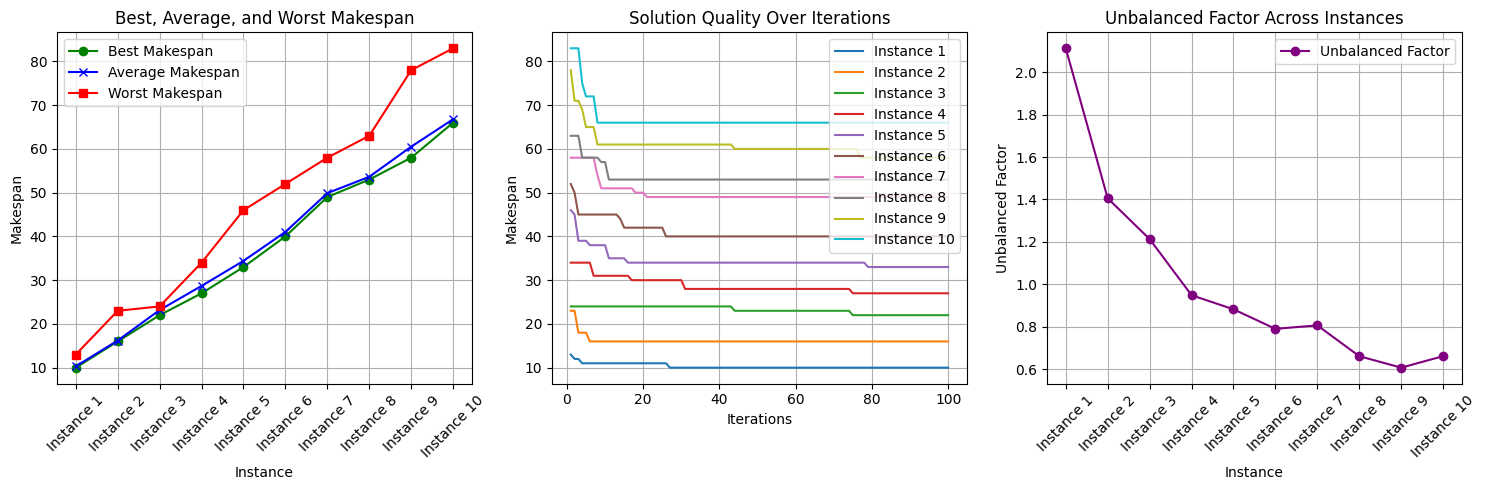

<ipython-input-5-d5b5252b6a9d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


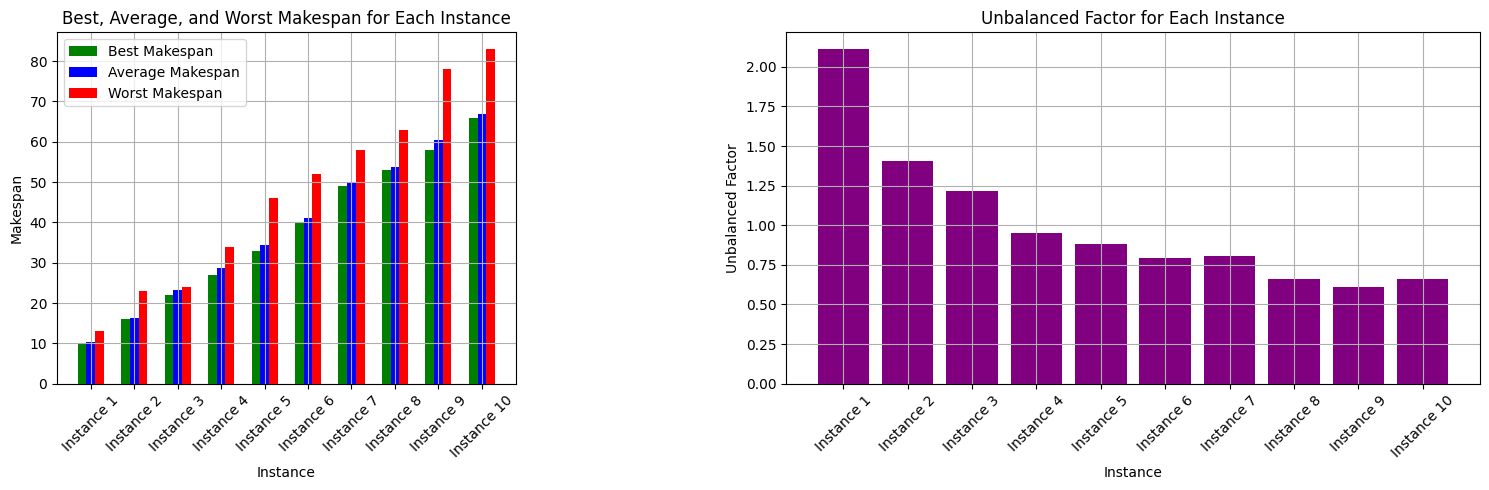

In [ ]:
filename = "instances.txt"  # File containing all instances
results = evaluate_instances_from_file("OACS", filename)
plot_instance_results(results)

# Modified

This section contains an evaluation of the performance of the proposed (modified) ant colony algorithm in the task scheduling problem.

AS

In [ ]:
def as_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Virtual Ant (Greedy Solution)
        greedy_solution = []
        vm_loads = {vm: 0 for vm in vms}  # Load for each VM
        for task in tasks:
            # Greedy choice: Choose VM with the minimum increase in makespan
            best_vm = None
            best_makespan_increase = float('inf')

            for vm_idx, vm in enumerate(vms):
                increase_in_makespan = max(vm_loads[vm] + time_matrix[task - 1, vm_idx] - max(list(vm_loads.values()), default=0), 0)
                if increase_in_makespan < best_makespan_increase:
                    best_makespan_increase = increase_in_makespan
                    best_vm = vm

            # Assign task to the best VM
            greedy_solution.append((task, best_vm))
            vm_loads[best_vm] += time_matrix[task - 1, vms.index(best_vm)]

        # Calculate Makespan for the greedy solution
        greedy_makespan = max(vm_loads.values())
        if greedy_makespan < best_makespan:
            best_solution = greedy_solution
            best_makespan = greedy_makespan


        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    # Calculate the heuristic value based on Makespan increase
                    increase_in_makespan = max(vm_loads[vm] + time_matrix[task - 1, vm_idx] - max(list(vm_loads.values()), default=0), 0)
                    heuristic = 1 / (increase_in_makespan + 1)  # Avoid division by zero

                    # Calculate the pheromone and probability
                    pheromone = pheromone_matrix[task - 1, vm_idx] ** alpha
                    probability = pheromone * (heuristic ** beta)
                    probabilities.append(probability)

                # Normalize probabilities
                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                # Roulette Wheel Selection
                cumulative_probabilities = [sum(probabilities[:i+1]) for i in range(len(probabilities))]
                random_value = random.random()
                chosen_vm_idx = next(vm_idx for vm_idx, cumulative in enumerate(cumulative_probabilities) if random_value <= cumulative)
                chosen_vm = vms[chosen_vm_idx]

                # Update VM loads and solution
                task_time = time_matrix[task - 1, chosen_vm_idx]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Pheromone update
        pheromone_matrix *= (1 - rho)
        for i, solution in enumerate(all_solutions):
            pheromone_deposit = Q / (all_makespans[i] * (1 + all_ufs[i]))  # Adjust pheromone by UF
            for task, vm in solution:
                pheromone_matrix[task - 1, vms.index(vm)] += pheromone_deposit

        # Add Greedy Solution (Virtual Ant) to Pheromone Update
        pheromone_deposit = Q / greedy_makespan
        for task, vm in greedy_solution:
            pheromone_matrix[task - 1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors


Evaluating Instance 1
Instance 1: Best Makespan = 8, Average Makespan = 8.00, Worst Makespan = 8, Unbalanced Factor = 0.6432
Evaluating Instance 2
Instance 2: Best Makespan = 13, Average Makespan = 13.03, Worst Makespan = 14, Unbalanced Factor = 0.2604
Evaluating Instance 3
Instance 3: Best Makespan = 18, Average Makespan = 18.42, Worst Makespan = 23, Unbalanced Factor = 0.3453
Evaluating Instance 4
Instance 4: Best Makespan = 24, Average Makespan = 25.12, Worst Makespan = 29, Unbalanced Factor = 0.2526
Evaluating Instance 5
Instance 5: Best Makespan = 30, Average Makespan = 30.45, Worst Makespan = 33, Unbalanced Factor = 0.2164
Evaluating Instance 6
Instance 6: Best Makespan = 35, Average Makespan = 35.73, Worst Makespan = 38, Unbalanced Factor = 0.1741
Evaluating Instance 7
Instance 7: Best Makespan = 42, Average Makespan = 42.56, Worst Makespan = 47, Unbalanced Factor = 0.1589
Evaluating Instance 8
Instance 8: Best Makespan = 47, Average Makespan = 48.40, Worst Makespan = 52, Unbala

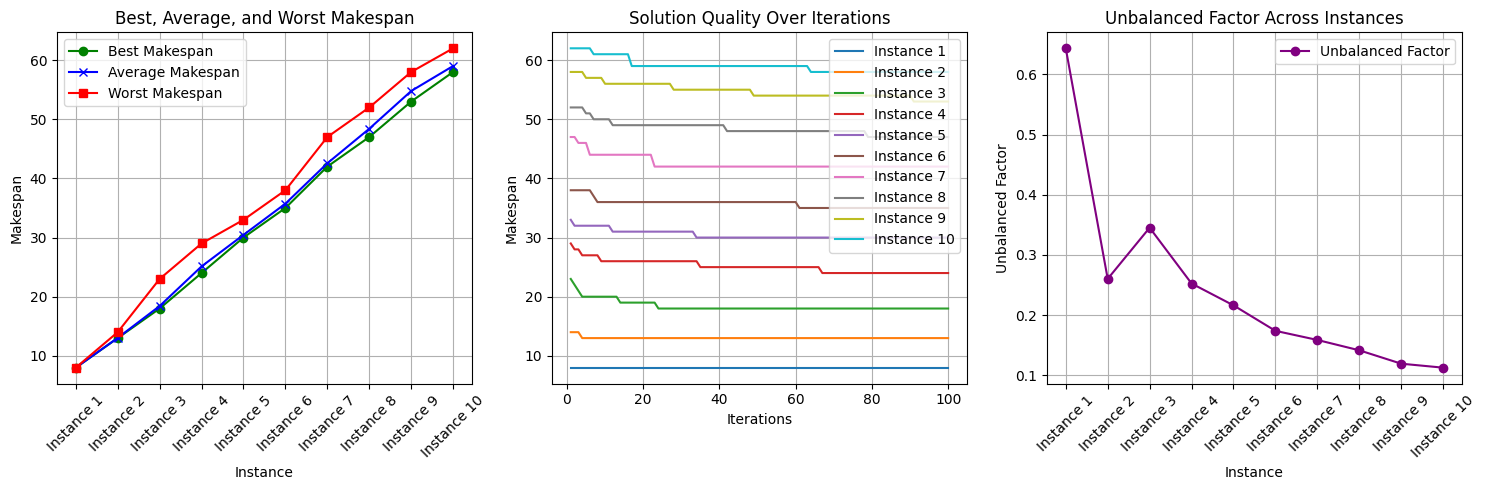

<ipython-input-3-44398d8565cc>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


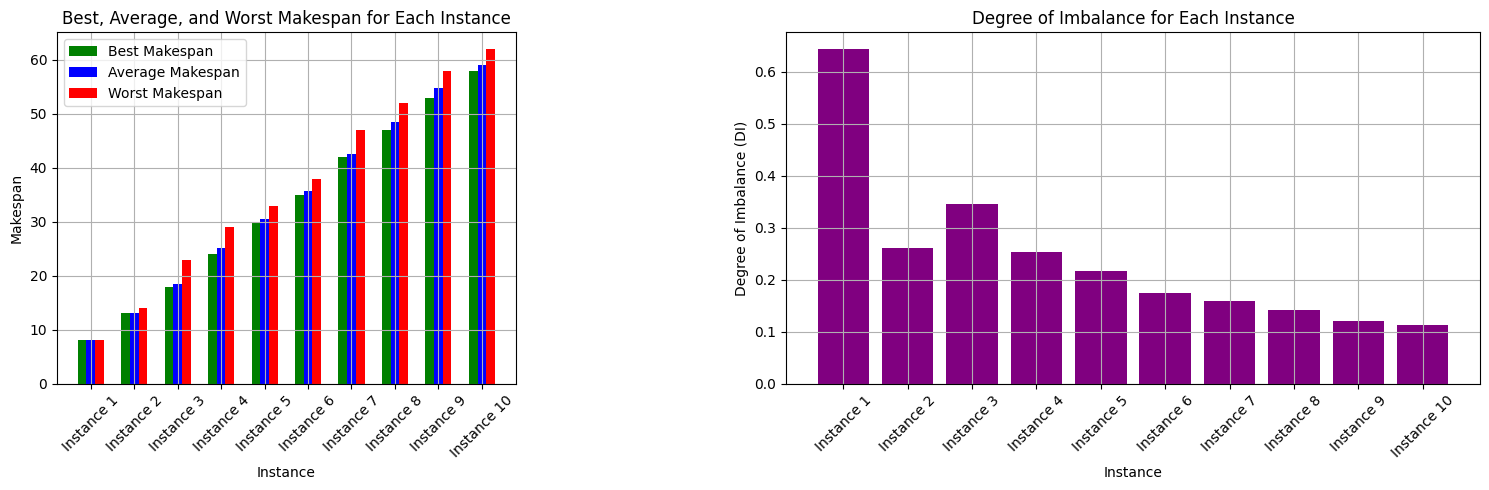

In [ ]:
filename = "instances.txt"  # File containing all instances
results = evaluate_instances_from_file("AS", filename)
plot_instance_results(results)

---

ACO

In [ ]:
# Function for Ant Colony Optimization
def acs_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Virtual Ant (Greedy Solution)
        greedy_solution = []
        vm_loads = {vm: 0 for vm in vms}  # Load for each VM
        for task in tasks:
            # Greedy choice: Choose VM with the minimum increase in makespan
            best_vm = None
            best_makespan_increase = float('inf')

            for vm_idx, vm in enumerate(vms):
                increase_in_makespan = max(vm_loads[vm] + time_matrix[task - 1, vm_idx] - max(list(vm_loads.values()), default=0), 0)
                if increase_in_makespan < best_makespan_increase:
                    best_makespan_increase = increase_in_makespan
                    best_vm = vm

            # Assign task to the best VM
            greedy_solution.append((task, best_vm))
            vm_loads[best_vm] += time_matrix[task - 1, vms.index(best_vm)]

        # Calculate Makespan for the greedy solution
        greedy_makespan = max(vm_loads.values())
        if greedy_makespan < best_makespan:
            best_solution = greedy_solution
            best_makespan = greedy_makespan

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    increase_in_makespan = max(vm_loads[vm] + time_matrix[task - 1, vm_idx] - max(list(vm_loads.values()), default=0), 0)
                    heuristic = 1 / (increase_in_makespan + 1)  # Avoid division by zero

                    pheromone = pheromone_matrix[task - 1, vm_idx] ** alpha
                    probability = pheromone * (heuristic ** beta)
                    probabilities.append(probability)

                # Normalize probabilities
                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                # Roulette Wheel Selection
                cumulative_probabilities = [sum(probabilities[:i + 1]) for i in range(len(probabilities))]
                random_value = random.random()
                chosen_vm_idx = next(vm_idx for vm_idx, cumulative in enumerate(cumulative_probabilities) if random_value <= cumulative)
                chosen_vm = vms[chosen_vm_idx]

                # Update VM loads and solution
                task_time = time_matrix[task - 1, chosen_vm_idx]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

                # Local Update: Update pheromone for the chosen task-VM pair
                pheromone_matrix[task - 1, vms.index(chosen_vm)] = (1 - rho) * pheromone_matrix[task - 1, vms.index(chosen_vm)] + (rho * Q / task_time)

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Global Update: Only the best ant and the greedy solution update the pheromone matrix
        pheromone_matrix *= (1 - rho)
        for task, vm in best_solution:
            pheromone_deposit = Q / best_makespan
            pheromone_matrix[task - 1, vms.index(vm)] += pheromone_deposit
        for task, vm in greedy_solution:
            pheromone_deposit = Q / greedy_makespan
            pheromone_matrix[task - 1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors


In [ ]:
filename = "instances.txt"  # File containing all instances
results = evaluate_instances_from_file("ACS", filename)
plot_instance_results(results)

---

MMAS

In [ ]:
# Function for Min-Max Ant System (MMAS)
def mmas_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution


        # Virtual Ant (Greedy Solution)
        greedy_solution = []
        vm_loads = {vm: 0 for vm in vms}  # Load for each VM
        for task in tasks:
            # Greedy choice: Choose VM with the minimum increase in makespan
            best_vm = None
            best_makespan_increase = float('inf')

            for vm_idx, vm in enumerate(vms):
                increase_in_makespan = max(vm_loads[vm] + time_matrix[task - 1, vm_idx] - max(list(vm_loads.values()), default=0), 0)
                if increase_in_makespan < best_makespan_increase:
                    best_makespan_increase = increase_in_makespan
                    best_vm = vm

            # Assign task to the best VM
            greedy_solution.append((task, best_vm))
            vm_loads[best_vm] += time_matrix[task - 1, vms.index(best_vm)]

        # Calculate Makespan for the greedy solution
        greedy_makespan = max(vm_loads.values())
        if greedy_makespan < best_makespan:
            best_solution = greedy_solution
            best_makespan = greedy_makespan


        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    # Calculate the heuristic value based on Makespan increase
                    increase_in_makespan = max(vm_loads[vm] + time_matrix[task - 1, vm_idx] - max(list(vm_loads.values()), default=0), 0)
                    heuristic = 1 / (increase_in_makespan + 1)  # Avoid division by zero

                    # Calculate the pheromone and probability
                    pheromone = pheromone_matrix[task - 1, vm_idx] ** alpha
                    probability = pheromone * (heuristic ** beta)
                    probabilities.append(probability)

                # Normalize probabilities
                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                # Roulette Wheel Selection
                cumulative_probabilities = [sum(probabilities[:i+1]) for i in range(len(probabilities))]
                random_value = random.random()
                chosen_vm_idx = next(vm_idx for vm_idx, cumulative in enumerate(cumulative_probabilities) if random_value <= cumulative)
                chosen_vm = vms[chosen_vm_idx]

                # Update VM loads and solution
                task_time = time_matrix[task - 1, chosen_vm_idx]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Compare Greedy Solution with Iteration Best and Global Best
        if greedy_makespan < best_makespan:
            best_solution = greedy_solution
            best_makespan = greedy_makespan

        # Pheromone update (Global Best Only)
        pheromone_matrix *= (1 - rho)
        pheromone_deposit = Q / best_makespan
        for task, vm in best_solution:
            pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Apply Min-Max limits to pheromone values
        pheromone_matrix = np.clip(pheromone_matrix, tau_min, tau_max)

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors


Evaluating Instance 1
Instance 1: Best Makespan = 7, Average Makespan = 7.05, Worst Makespan = 8, Unbalanced Factor = 0.3625
Evaluating Instance 2
Instance 2: Best Makespan = 12, Average Makespan = 12.04, Worst Makespan = 13, Unbalanced Factor = 0.1939
Evaluating Instance 3
Instance 3: Best Makespan = 19, Average Makespan = 19.12, Worst Makespan = 22, Unbalanced Factor = 0.1813
Evaluating Instance 4
Instance 4: Best Makespan = 25, Average Makespan = 25.04, Worst Makespan = 27, Unbalanced Factor = 0.1240
Evaluating Instance 5
Instance 5: Best Makespan = 32, Average Makespan = 32.02, Worst Makespan = 33, Unbalanced Factor = 0.1734
Evaluating Instance 6
Instance 6: Best Makespan = 37, Average Makespan = 37.10, Worst Makespan = 38, Unbalanced Factor = 0.1828
Evaluating Instance 7
Instance 7: Best Makespan = 44, Average Makespan = 45.32, Worst Makespan = 46, Unbalanced Factor = 0.1434
Evaluating Instance 8
Instance 8: Best Makespan = 51, Average Makespan = 51.08, Worst Makespan = 52, Unbala

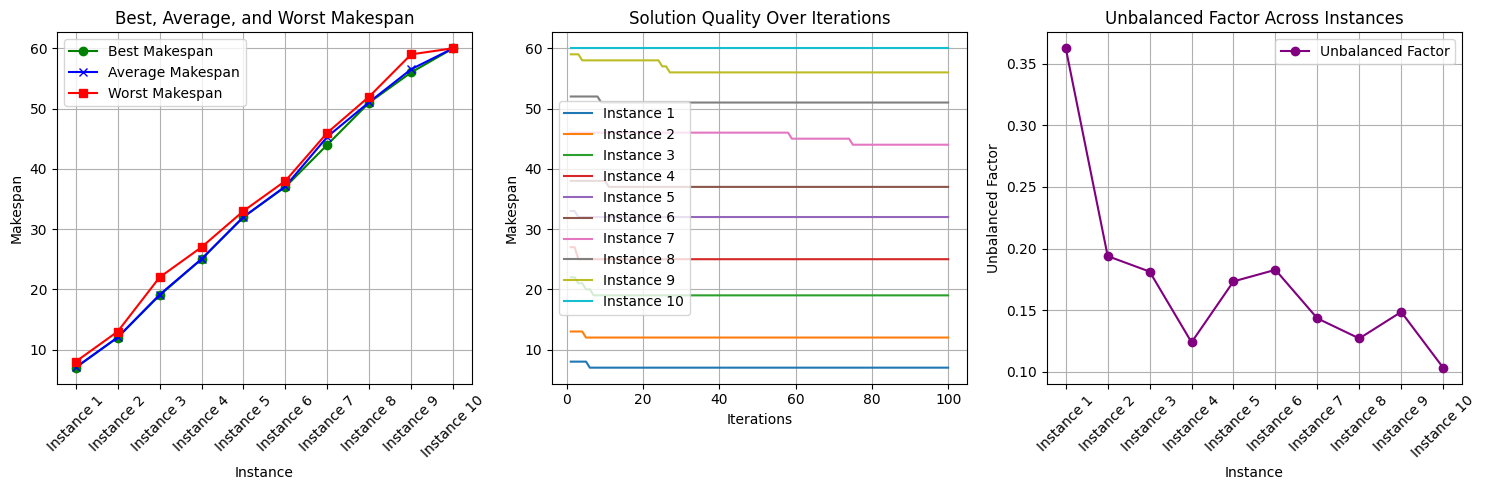

<ipython-input-5-d5b5252b6a9d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


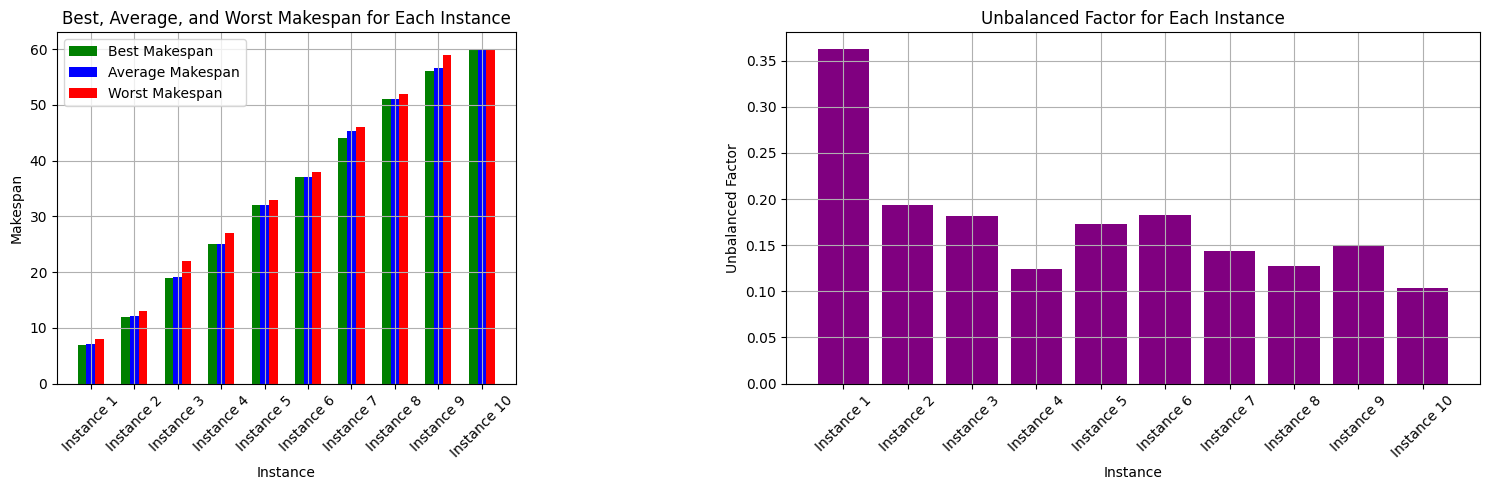

In [ ]:
filename = "instances.txt"  # File containing all instances
results = evaluate_instances_from_file("MMAS", filename)
plot_instance_results(results)

# Comparison

In this section we compare the performance of the original and modified ant colony algorithms.

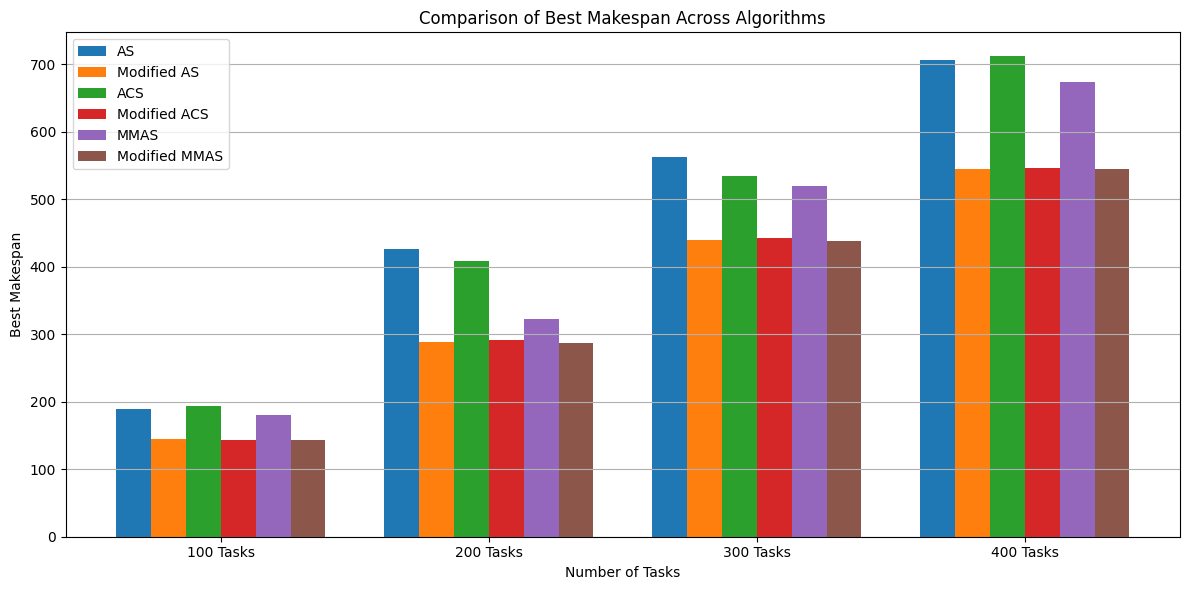

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated results for six algorithms across five instances (example data)
algorithms = ["AS", "Modified AS", "ACS", "Modified ACS", "MMAS", "Modified MMAS"]
instances = [f"{i+1}00 Tasks" for i in range(4)]

# Example performance data (best makespans)
best_makespans_data = {
    "AS": [189.09, 427.05, 563.25, 705.96],
    "Modified AS": [145.41, 288.22, 439.7, 545.51],
    "ACS": [193.29 , 408.91, 535.21, 712.06],
    "Modified ACS": [144.07, 291.16, 442.12, 546.93],
    "MMAS": [180.49, 322.39, 519.23, 674.62],
    "Modified MMAS": [143.97, 287.88, 438.82, 545.8],
}

# Plotting the best makespans comparison
plt.figure(figsize=(12, 6))
bar_width = 0.13
x = np.arange(len(instances))

for i, algo in enumerate(algorithms):
    plt.bar(x + i * bar_width, best_makespans_data[algo], width=bar_width, label=algo)

plt.xlabel("Number of Tasks")
plt.ylabel("Best Makespan")
plt.title("Comparison of Best Makespan Across Algorithms")
plt.xticks(x + bar_width * (len(algorithms)-1) / 2, instances)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
# Save as high-quality PDF (vector format)
plt.savefig("best_makespan_comparison.pdf", format='pdf', bbox_inches='tight')

plt.show()



DI comparison

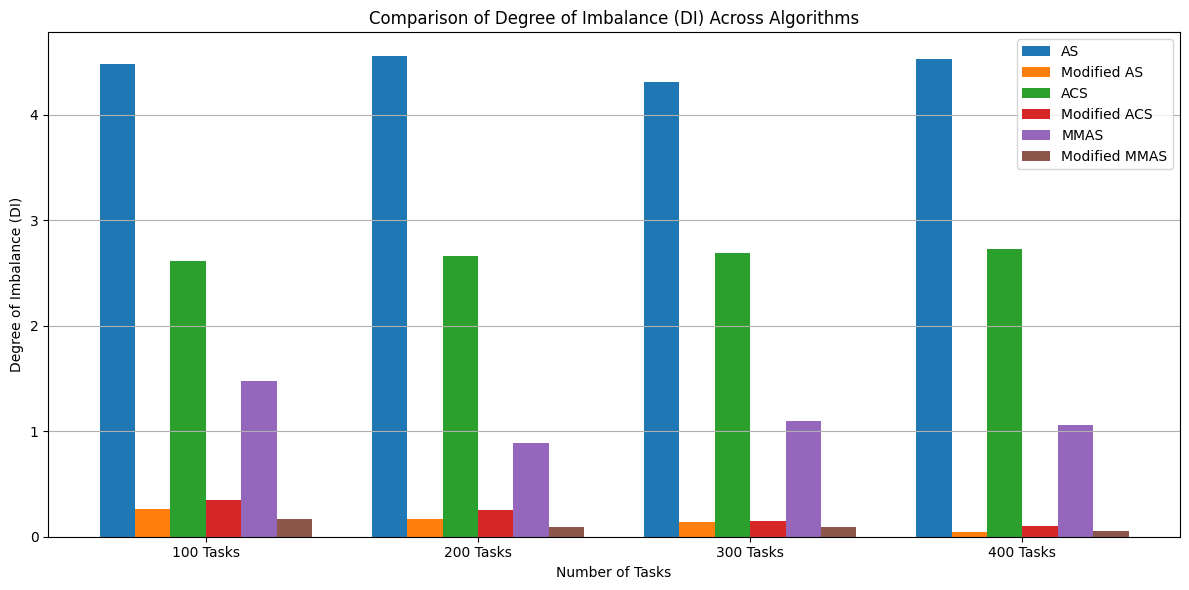

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated results for six algorithms across five instances (example data)
algorithms = ["AS", "Modified AS", "ACS", "Modified ACS", "MMAS", "Modified MMAS"]
instances = [f"{i+1}00 Tasks" for i in range(4)]

# Example performance data (Degree of Imbalance (DI))
best_makespans_data = {
    "AS": [4.4817, 4.5557, 4.3102, 4.5267],
    "Modified AS": [0.2594, 0.1654, 0.1363, 0.0458],
    "ACS": [2.6166, 2.6669, 2.6895, 2.7309],
    "Modified ACS": [0.3506, 0.2532, 0.1536, 0.0974],
    "MMAS": [1.4810, 0.8849, 1.1016, 1.0614],
    "Modified MMAS": [0.1698, 0.0954, 0.0906, 0.0561],
}

# Plotting the Degree of Imbalance (DI) comparison
plt.figure(figsize=(12, 6))
bar_width = 0.13
x = np.arange(len(instances))

for i, algo in enumerate(algorithms):
    plt.bar(x + i * bar_width, best_makespans_data[algo], width=bar_width, label=algo)

plt.xlabel("Number of Tasks")
plt.ylabel("Degree of Imbalance (DI)")
plt.title("Comparison of Degree of Imbalance (DI) Across Algorithms")
plt.xticks(x + bar_width * (len(algorithms)-1) / 2, instances)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
# Save as high-quality PDF (vector format)
plt.savefig("best_DI_comparison.pdf", format='pdf', bbox_inches='tight')

plt.show()


# GoCJ Execution time

In [ ]:
def load_gocj_data(files):
    """
    Loads GOCJ data from a list of files. Each file contains task sizes.
    Returns a list of task sizes for each file.
    """
    gocj_data = []
    for file in files:
        with open(file, 'r') as f:
            task_sizes = [int(line.strip()) for line in f.readlines()]
            gocj_data.append(task_sizes)
    return gocj_data

def calculate_execution_times(task_sizes, vm_capabilities):
    """
    Calculates the execution times for tasks on VMs.
    task_sizes: List of task sizes.
    vm_capabilities: List of VM processing capabilities.
    Returns a time matrix with execution times.
    """
    time_matrix = []
    for task_size in task_sizes:
        times = [task_size / capability for capability in vm_capabilities]
        time_matrix.append(times)
    return time_matrix

def generate_instances_from_gocj(files, vm_capabilities):
    """
    Generates instances based on GOCJ data and VM capabilities.
    files: List of file paths for GOCJ data.
    vm_capabilities: List of processing capabilities for VMs.
    Returns a list of instances.
    """
    gocj_data = load_gocj_data(files)
    instances = []
    for task_sizes in gocj_data:
        total_tasks = len(task_sizes)
        total_machines = len(vm_capabilities)

        tasks = list(range(1, total_tasks + 1))
        machines = list(range(1, total_machines + 1))
        time_matrix = calculate_execution_times(task_sizes, vm_capabilities)

        instances.append((tasks, machines, time_matrix))
    return instances

def save_instances_to_file(filename, instances):
    """
    Saves multiple instances to a file, separated by a delimiter.
    """
    with open(filename, 'w') as file:
        for idx, instance in enumerate(instances):
            tasks, machines, time_matrix = instance

            # Write task IDs
            file.write(" ".join(map(str, tasks)) + "\n")

            # Write machine IDs
            file.write(" ".join(map(str, machines)) + "\n")

            # Write time matrix
            for row in time_matrix:
                file.write(" ".join(f"{value:.2f}" for value in row) + "\n")

            # Add delimiter between instances (except after the last instance)
            if idx < len(instances) - 1:
                file.write("---\n")

# Define VM processing capabilities
vm_capabilities = [5000, 6000, 7000, 8000, 9500, 10000, 11000, 12000, 13000, 14000,5000, 6000, 7000, 8000, 9500, 10000, 11000, 12000, 13000, 14000, 5000, 6000, 7000, 8000, 9500, 10000, 11000, 12000, 13000, 14000,5000, 6000, 7000, 8000, 9500, 10000, 11000, 12000, 13000, 14000]  # Example values

# Define paths to GOCJ files
gocj_files = [
    "GoCJ_Dataset_100.txt",
    "GoCJ_Dataset_200.txt",
    "GoCJ_Dataset_300.txt",
    "GoCJ_Dataset_400.txt"
]

# Generate instances from GOCJ data
instances = generate_instances_from_gocj(gocj_files, vm_capabilities)

# Save instances to a file
output_filename = "gocj_instances.txt"
save_instances_to_file(output_filename, instances)
print(f"Instances saved to {output_filename}.")


Instances saved to gocj_instances.txt.


In [ ]:
def load_instances_from_file(filename):
    """
    Loads multiple instances from a single file.
    Each instance is separated by a delimiter (e.g., '---').
    """
    instances = []
    with open(filename, 'r') as file:
        content = file.read().strip().split('---')  # Split instances by delimiter
        for instance_data in content:
            lines = instance_data.strip().split('\n')
            if len(lines) < 3:  # Skip empty or invalid instances
                continue

            # Parse tasks: Split based on spaces
            tasks = list(map(int, lines[0].strip().split()))

            # Parse machines: Split based on spaces
            machines = list(map(int, lines[1].strip().split()))

            # Parse time matrix
            time_matrix = [list(map(float, line.strip().split())) for line in lines[2:]]

            # Verify dimensions
            assert len(time_matrix) == len(tasks), \
                f"Expected {len(tasks)} rows in time_matrix, but got {len(time_matrix)}."
            for row in time_matrix:
                assert len(row) == len(machines), \
                    f"Expected {len(machines)} columns in time_matrix row, but got {len(row)}."

            # Store the instance
            instances.append({
                "tasks": tasks,
                "machines": machines,
                "time_matrix": time_matrix
            })

    return instances


Evaluating Instance 1
Instance 1: Best Makespan = 64.29, Average Makespan = 64.29, Worst Makespan = 64.29, Unbalanced Factor = 1.8522
Evaluating Instance 2
Instance 2: Best Makespan = 80.61999999999999, Average Makespan = 82.58, Worst Makespan = 92.64, Unbalanced Factor = 0.9251
Evaluating Instance 3
Instance 3: Best Makespan = 117.57000000000001, Average Makespan = 118.38, Worst Makespan = 125.24, Unbalanced Factor = 0.7495
Evaluating Instance 4
Instance 4: Best Makespan = 147.46, Average Makespan = 147.46, Worst Makespan = 147.46, Unbalanced Factor = 0.5546


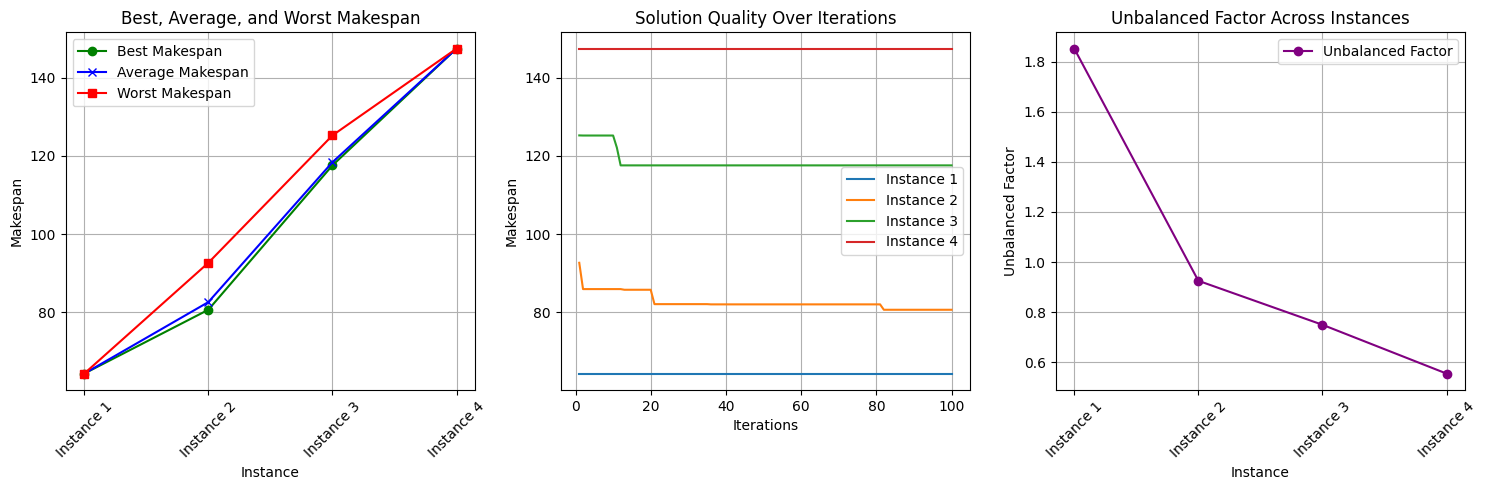

<ipython-input-6-44398d8565cc>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


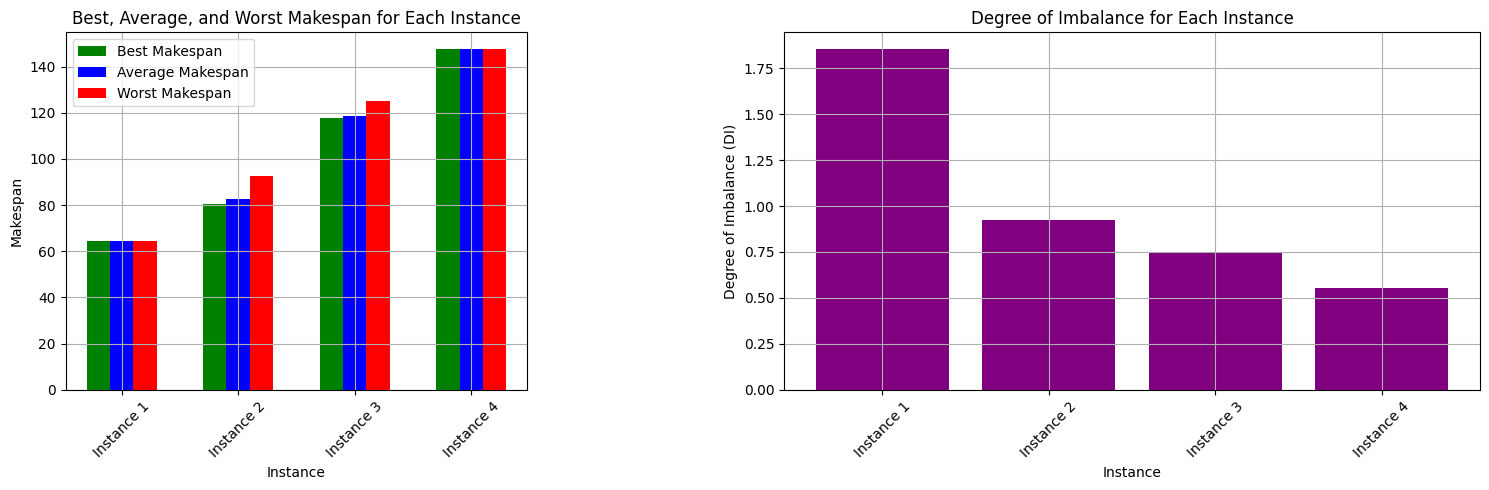

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("AS", filename)
plot_instance_results(results)

Evaluating Instance 1
Instance 1: Best Makespan = 224.84000000000003, Average Makespan = 224.97, Worst Makespan = 238.05000000000004, Unbalanced Factor = 4.5030
Evaluating Instance 2
Instance 2: Best Makespan = 401.29, Average Makespan = 401.29, Worst Makespan = 401.29, Unbalanced Factor = 4.2590
Evaluating Instance 3
Instance 3: Best Makespan = 603.86, Average Makespan = 603.86, Worst Makespan = 603.86, Unbalanced Factor = 4.4827
Evaluating Instance 4
Instance 4: Best Makespan = 686.72, Average Makespan = 687.15, Worst Makespan = 730.12, Unbalanced Factor = 4.4798


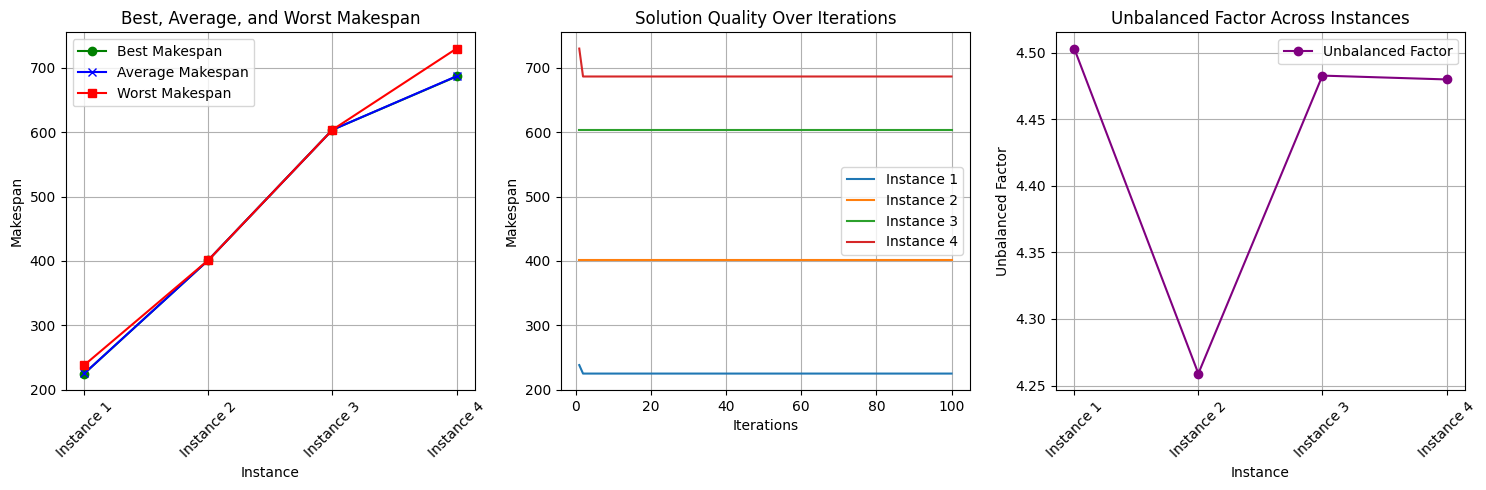

<ipython-input-3-44398d8565cc>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


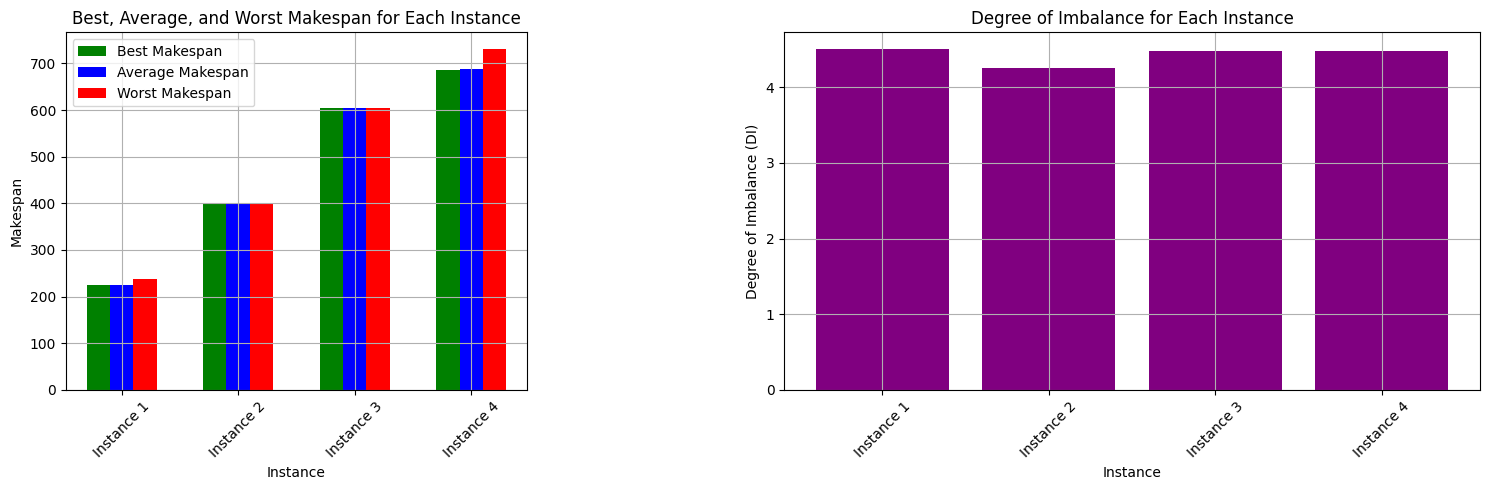

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("OAS", filename)
plot_instance_results(results)

Evaluating Instance 1
Instance 1: Best Makespan = 146.26999999999998, Average Makespan = 147.06, Worst Makespan = 157.36, Unbalanced Factor = 0.3677
Evaluating Instance 2
Instance 2: Best Makespan = 288.09, Average Makespan = 289.07, Worst Makespan = 302.09999999999997, Unbalanced Factor = 0.2347
Evaluating Instance 3
Instance 3: Best Makespan = 441.33000000000004, Average Makespan = 451.32, Worst Makespan = 460.19000000000005, Unbalanced Factor = 0.1552
Evaluating Instance 4
Instance 4: Best Makespan = 548.13, Average Makespan = 548.13, Worst Makespan = 548.13, Unbalanced Factor = 0.1019


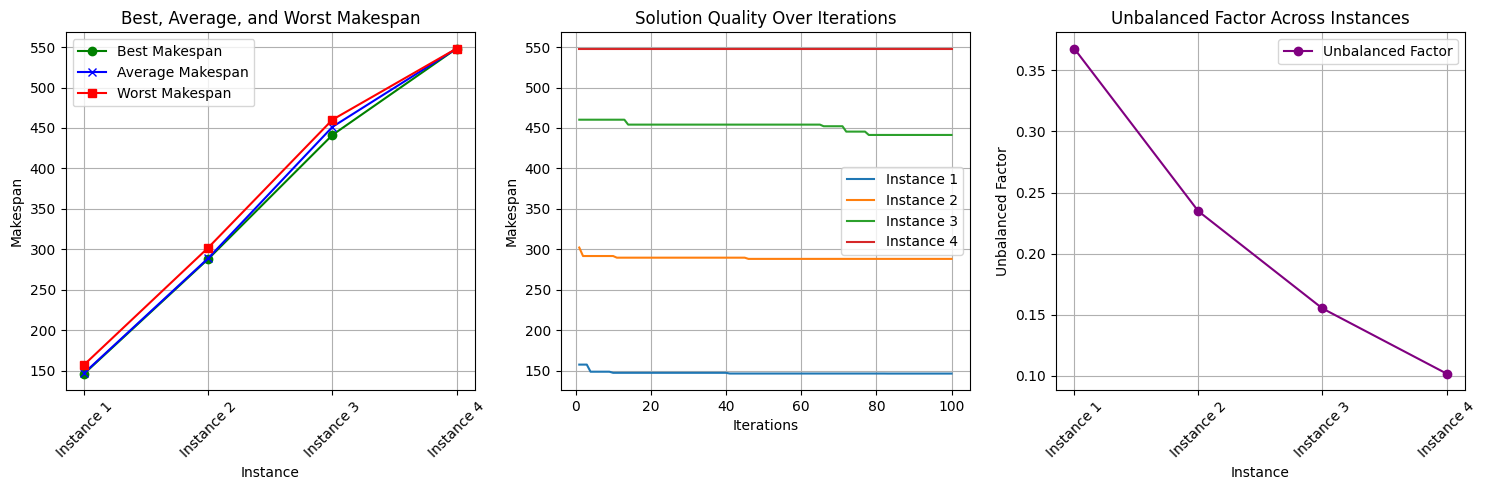

<ipython-input-3-44398d8565cc>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


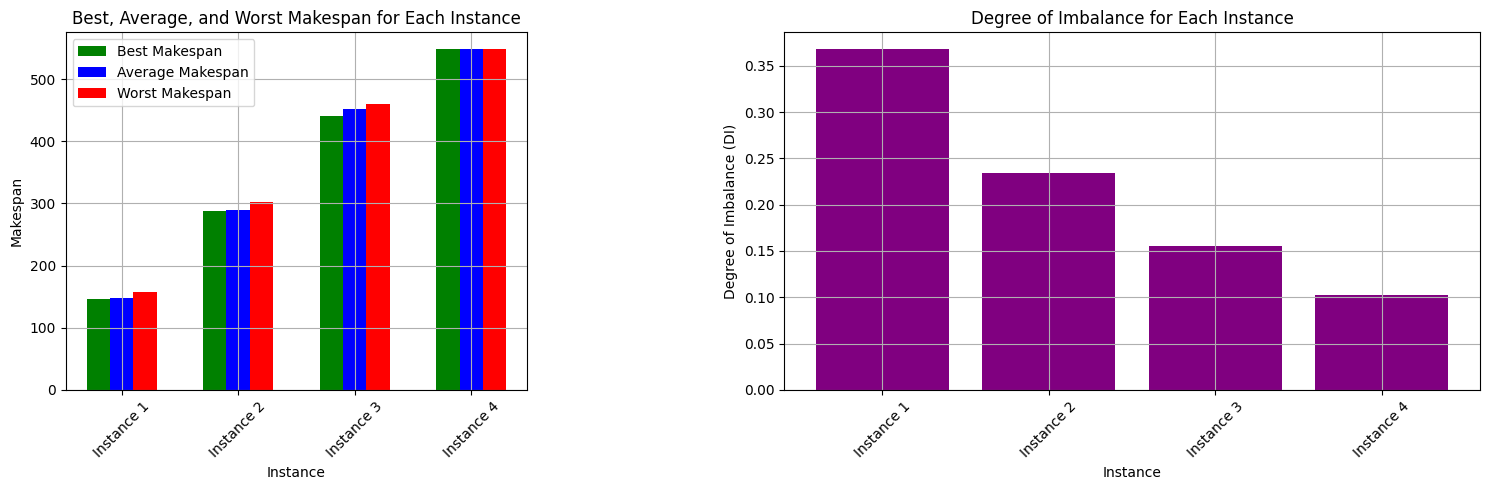

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("ACS", filename)
plot_instance_results(results)

Evaluating Instance 1
Instance 1: Best Makespan = 226.02000000000004, Average Makespan = 226.02, Worst Makespan = 226.02000000000004, Unbalanced Factor = 2.5680
Evaluating Instance 2
Instance 2: Best Makespan = 454.83, Average Makespan = 454.83, Worst Makespan = 454.83, Unbalanced Factor = 2.5982
Evaluating Instance 3
Instance 3: Best Makespan = 587.9800000000001, Average Makespan = 587.98, Worst Makespan = 587.9800000000001, Unbalanced Factor = 2.6537
Evaluating Instance 4
Instance 4: Best Makespan = 749.22, Average Makespan = 749.22, Worst Makespan = 749.22, Unbalanced Factor = 2.7253


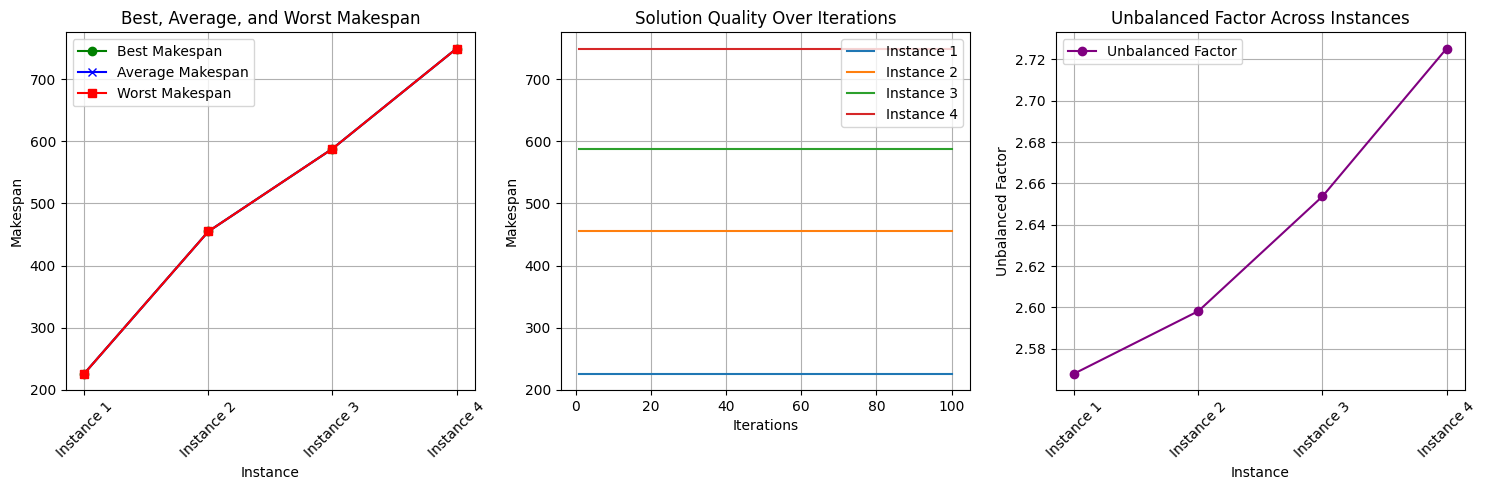

<ipython-input-3-44398d8565cc>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


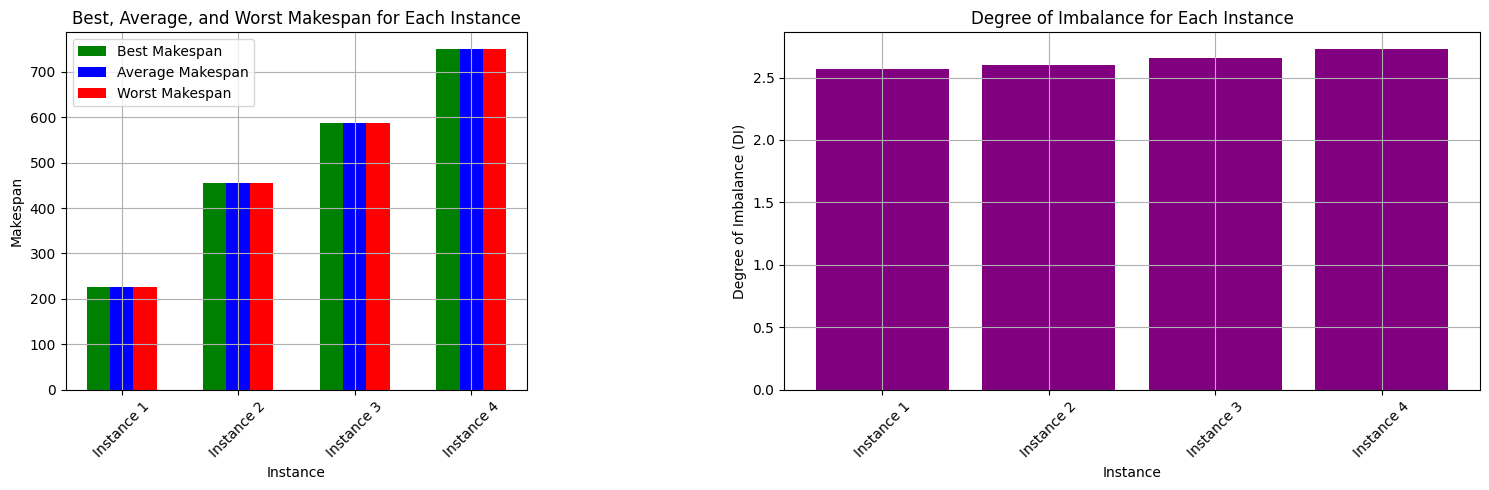

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("OACS", filename)
plot_instance_results(results)

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("MMAS", filename)
plot_instance_results(results)

Evaluating Instance 1
Instance 1: Best Makespan = 144.23, Average Makespan = 145.49, Worst Makespan = 159.0, Unbalanced Factor = 0.1692
Evaluating Instance 2
Instance 2: Best Makespan = 287.4, Average Makespan = 287.40, Worst Makespan = 287.4, Unbalanced Factor = 0.1467
Evaluating Instance 3
Instance 3: Best Makespan = 436.1, Average Makespan = 438.96, Worst Makespan = 463.21999999999997, Unbalanced Factor = 0.0739
Evaluating Instance 4
Instance 4: Best Makespan = 546.0, Average Makespan = 546.32, Worst Makespan = 548.13, Unbalanced Factor = 0.0451


In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("OMMAS", filename)
plot_instance_results(results)

# Taillard's Benchmark Instances

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import os

In [ ]:
def parse_taillard_instances(filepath):
    """
    Parses multiple Taillard instances from a file and returns a list of instances.
    Each instance is separated by the line:
    'Nb of jobs, Nb of Machines, Time seed, Machine seed, Upper bound, Lower bound'
    """
    with open(filepath, 'r') as file:
        content = file.read()

    # Split the content into individual instances based on the delimiter line
    delimiter = "Nb of jobs, Nb of Machines, Time seed, Machine seed, Upper bound, Lower bound"
    instances_raw = content.strip().split(delimiter)

    instances = []
    for instance_raw in instances_raw[1:]:  # Skip the first split (empty or irrelevant)
        lines = instance_raw.strip().split('\n')

        # Parse the number of tasks and machines from the first line of the instance
        header = lines[0].strip().split()
        num_tasks = int(header[0])  # Number of jobs (tasks)
        num_machines = int(header[1])  # Number of machines

        # Find the start of the Times section
        times_start = None
        for i, line in enumerate(lines):
            if line.strip() == "Times":
                times_start = i + 1
                break

        if times_start is None:
            raise ValueError("Could not find the 'Times' section in the instance data.")

        # Parse the time matrix
        time_matrix = []
        for line in lines[times_start:times_start + num_tasks]:
            row = list(map(int, line.strip().split()))
            time_matrix.append(row)

        # Generate task and machine IDs
        tasks = list(range(1, num_tasks + 1))
        machines = list(range(1, num_machines + 1))

        instances.append({
            "tasks": tasks,
            "machines": machines,
            "time_matrix": time_matrix
        })

    return instances

def save_parsed_instances(instances, output_folder):
    """
    Saves multiple parsed instances to files in the required format.
    Each instance is saved as a separate file in the output folder.
    """
    import os

    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)

    for i, instance in enumerate(instances):
        tasks = instance["tasks"]
        machines = instance["machines"]
        time_matrix = instance["time_matrix"]

        # Save each instance to a separate file
        output_file = os.path.join(output_folder, f"instance_{i + 1}.txt")
        with open(output_file, 'w') as file:
            # Write task IDs
            file.write(" ".join(map(str, tasks)) + "\n")

            # Write machine IDs
            file.write(" ".join(map(str, machines)) + "\n")

            # Write time matrix
            for row in time_matrix:
                file.write(" ".join(map(str, row)) + "\n")

        print(f"Instance {i + 1} saved to {output_file}.")

# Example usage
taillard_file = "tai20_5.txt"  # Path to Taillard instance file
output_folder = "parsed_instances"  # Folder to save parsed instances

# Parse and save all instances
instances = parse_taillard_instances(taillard_file)
save_parsed_instances(instances, output_folder)

Instance 1 saved to parsed_instances/instance_1.txt.
Instance 2 saved to parsed_instances/instance_2.txt.
Instance 3 saved to parsed_instances/instance_3.txt.
Instance 4 saved to parsed_instances/instance_4.txt.
Instance 5 saved to parsed_instances/instance_5.txt.
Instance 6 saved to parsed_instances/instance_6.txt.
Instance 7 saved to parsed_instances/instance_7.txt.
Instance 8 saved to parsed_instances/instance_8.txt.
Instance 9 saved to parsed_instances/instance_9.txt.
Instance 10 saved to parsed_instances/instance_10.txt.


Test on tai data with parsing

Processing instance: instance_1.txt
Processing instance: instance_7.txt
Processing instance: instance_2.txt
Processing instance: instance_4.txt
Processing instance: instance_5.txt
Processing instance: instance_8.txt
Processing instance: instance_3.txt
Processing instance: instance_10.txt
Processing instance: instance_6.txt
Processing instance: instance_9.txt
Instance	Best Makespan	Average Makespan	Worst Makespan	Unbalanced Factor
instance_1.txt	42		43.45		61		0.9219
instance_7.txt	40		42.07		76		0.8674
instance_2.txt	40		42.30		63		1.0030
instance_4.txt	45		47.53		79		1.2008
instance_5.txt	41		42.58		66		0.8946
instance_8.txt	39		41.43		81		0.9620
instance_3.txt	34		37.67		78		0.9137
instance_10.txt	31		32.71		59		0.9055
instance_6.txt	42		42.90		81		1.0080
instance_9.txt	43		43.98		63		1.0125


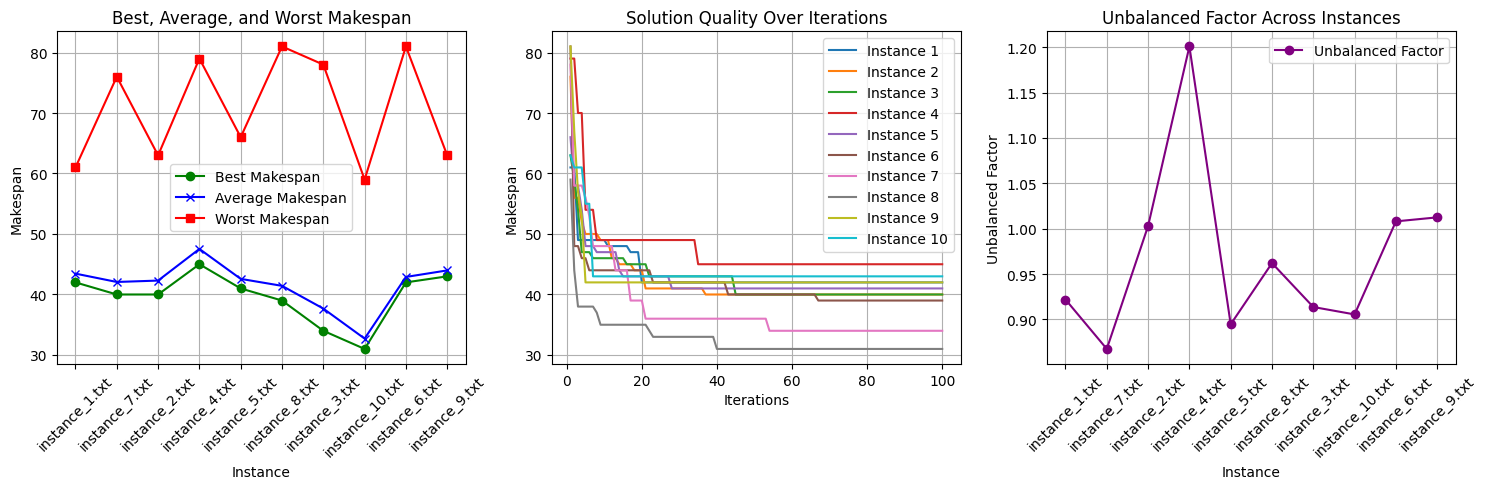

In [ ]:
# Function to read a parsed instance file
def read_parsed_instance(filepath):
    """
    Reads a parsed instance file and returns the tasks, machines, and time matrix.
    """
    try:
        with open(filepath, 'r') as file:
            lines = file.readlines()

        # Parse task IDs (first line)
        tasks = list(map(int, lines[0].strip().split()))

        # Parse machine IDs (second line)
        machines = list(map(int, lines[1].strip().split()))

        # Parse time matrix (remaining lines)
        time_matrix = []
        for line in lines[2:]:
            row = list(map(int, line.strip().split()))
            time_matrix.append(row)

        return {
            "tasks": tasks,
            "machines": machines,
            "time_matrix": time_matrix
        }
    except (FileNotFoundError, IndexError, ValueError) as e:
        print(f"Skipping file {filepath} due to error: {e}")
        return None

# Function to initialize pheromone matrix
def initialize_pheromones(tasks, vms):
    return np.ones((len(tasks), len(vms)))  # Initialize pheromone matrix with 1s

# ACO Parameters
n_ants = 10  # Number of ants (solutions)
n_iterations = 100  # Number of iterations
alpha = 1  # Influence of pheromone
beta = 2  # Influence of heuristic (task time)
gamma = 2  # Influence of load balance
rho = 0.1  # Pheromone evaporation rate
Q = 100  # Total pheromone to deposit

# Function for Ant Colony Optimization
def aco_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                    load_balance = (1 / (vm_loads[vm] + 1)) ** gamma  # Load Balancing Influence
                    probability = pheromone * heuristic * load_balance
                    probabilities.append(probability)

                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                chosen_vm = random.choices(vms, probabilities)[0]
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

                # Local Update: Update pheromone for the chosen task-VM pair
                pheromone_matrix[task-1, vms.index(chosen_vm)] = (1 - rho) * pheromone_matrix[task-1, vms.index(chosen_vm)] + (rho * Q / task_time)

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Global Update: Only the best ant updates the pheromone matrix
        pheromone_matrix *= (1 - rho)
        for task, vm in best_solution:
            pheromone_deposit = Q / best_makespan
            pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors

# Function to run ACO on all instances in a folder
def run_aco_on_folder(folder_path):
    results = []

    # Get all files in the folder
    instance_files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]

    for instance_file in instance_files:
        filepath = os.path.join(folder_path, instance_file)
        print(f"Processing instance: {instance_file}")

        # Read the parsed instance
        instance = read_parsed_instance(filepath)
        if instance is None:
            continue  # Skip invalid files

        tasks = instance["tasks"]
        machines = instance["machines"]
        time_matrix = np.array(instance["time_matrix"])

        # Initialize pheromones and heuristic matrix
        pheromone_matrix = initialize_pheromones(tasks, machines)
        heuristic_matrix = 1 / (time_matrix + 1e-10)

        # Run ACO for the current instance
        best_solution, best_makespan, solution_quality, uf = aco_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)

        # Store results for this instance
        results.append({
            "instance": instance_file,
            "best_makespan": best_makespan,
            "average_makespan": np.mean(solution_quality),
            "worst_makespan": np.max(solution_quality),
            "unbalanced_factor": np.mean(uf),
            "solution_quality": solution_quality
        })

    return results

# Function to plot results
def plot_results(results):
    """
    Plots the results:
    1. Best, Average, and Worst Makespan across instances.
    2. Solution Quality (makespan over iterations) for all instances.
    3. Unbalanced Factor across instances.
    """
    instance_names = [result["instance"] for result in results]
    best_makespans = [result["best_makespan"] for result in results]
    average_makespans = [result["average_makespan"] for result in results]
    worst_makespans = [result["worst_makespan"] for result in results]
    unbalanced_factors = [result["unbalanced_factor"] for result in results]
    solution_qualities = [result["solution_quality"] for result in results]

    plt.figure(figsize=(15, 5))

    # Plot 1: Best, Average, and Worst Makespan
    plt.subplot(1, 3, 1)
    plt.plot(instance_names, best_makespans, label="Best Makespan", marker="o", color="green")
    plt.plot(instance_names, average_makespans, label="Average Makespan", marker="x", color="blue")
    plt.plot(instance_names, worst_makespans, label="Worst Makespan", marker="s", color="red")
    plt.xlabel("Instance")
    plt.ylabel("Makespan")
    plt.title("Best, Average, and Worst Makespan")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    # Plot 2: Solution Quality (Makespan over iterations)
    plt.subplot(1, 3, 2)
    for i, solution_quality in enumerate(solution_qualities):
        plt.plot(range(1, len(solution_quality) + 1), solution_quality, label=f"Instance {i + 1}")
    plt.xlabel("Iterations")
    plt.ylabel("Makespan")
    plt.title("Solution Quality Over Iterations")
    plt.legend()
    plt.grid(True)

    # Plot 3: Unbalanced Factor
    plt.subplot(1, 3, 3)
    plt.plot(instance_names, unbalanced_factors, label="Unbalanced Factor", marker="o", color="purple")
    plt.xlabel("Instance")
    plt.ylabel("Unbalanced Factor")
    plt.title("Unbalanced Factor Across Instances")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage
parsed_folder = "parsed_instances"  # Folder containing parsed instance files

# Run ACO on all instances in the folder
results = run_aco_on_folder(parsed_folder)

# Print results
print("Instance\tBest Makespan\tAverage Makespan\tWorst Makespan\tUnbalanced Factor")
for result in results:
    print(f"{result['instance']}\t{result['best_makespan']}\t\t{result['average_makespan']:.2f}\t\t{result['worst_makespan']}\t\t{result['unbalanced_factor']:.4f}")

# Plot results
plot_results(results)

 Teat ACO on tai data without parsing

Instance	Best Makespan	Average Makespan	Worst Makespan	Unbalanced Factor
1		42		44.11		68		0.9366
2		42		43.34		88		0.9852
3		36		38.87		61		0.8811
4		42		44.61		74		1.1626
5		41		42.64		63		0.9410
6		40		43.60		71		0.9895
7		38		40.90		85		0.9332
8		41		42.59		62		0.9708
9		40		42.35		77		1.0119
10		32		33.21		64		0.8670


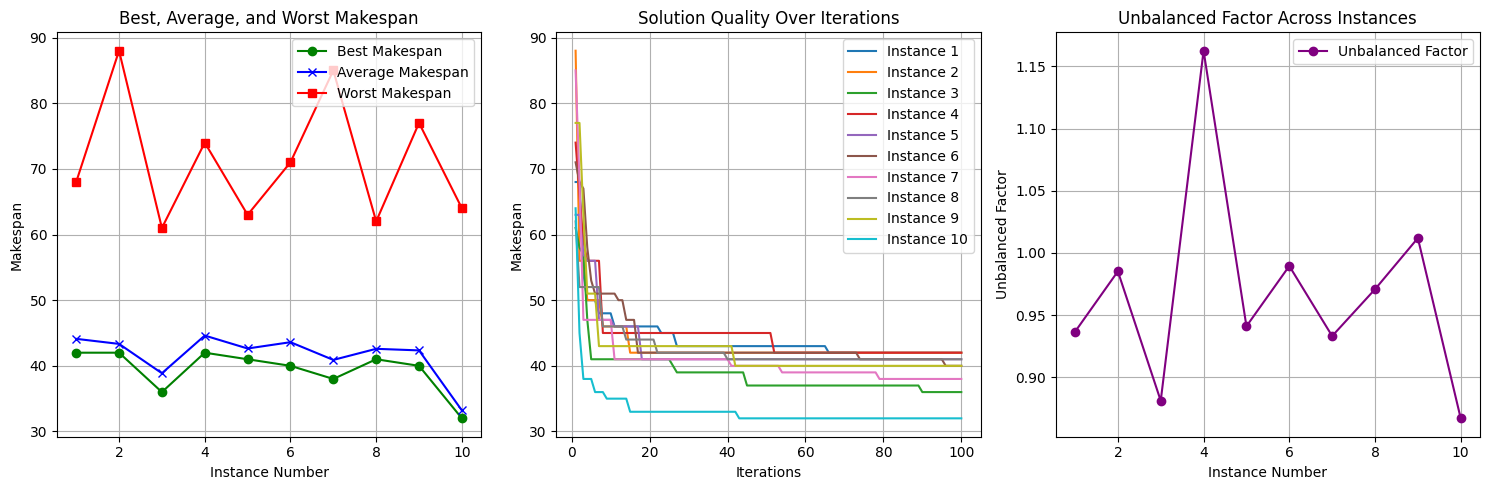

In [ ]:
# Function to parse Taillard instances
def parse_taillard_instances(filepath):
    """
    Parses multiple Taillard instances from a file and returns a list of instances.
    Each instance is separated by the line:
    'Nb of jobs, Nb of Machines, Time seed, Machine seed, Upper bound, Lower bound'
    """
    with open(filepath, 'r') as file:
        content = file.read()

    # Split the content into individual instances based on the delimiter line
    delimiter = "Nb of jobs, Nb of Machines, Time seed, Machine seed, Upper bound, Lower bound"
    instances_raw = content.strip().split(delimiter)

    instances = []
    for instance_raw in instances_raw[1:]:  # Skip the first split (empty or irrelevant)
        lines = instance_raw.strip().split('\n')

        # Parse the number of tasks and machines from the first line of the instance
        header = lines[0].strip().split()
        num_tasks = int(header[0])  # Number of jobs (tasks)
        num_machines = int(header[1])  # Number of machines

        # Find the start of the Times section
        times_start = None
        for i, line in enumerate(lines):
            if line.strip() == "Times":
                times_start = i + 1
                break

        if times_start is None:
            raise ValueError("Could not find the 'Times' section in the instance data.")

        # Parse the time matrix
        time_matrix = []
        for line in lines[times_start:times_start + num_tasks]:
            row = list(map(int, line.strip().split()))
            time_matrix.append(row)

        # Generate task and machine IDs
        tasks = list(range(1, num_tasks + 1))
        machines = list(range(1, num_machines + 1))

        instances.append({
            "tasks": tasks,
            "machines": machines,
            "time_matrix": time_matrix
        })

    return instances

# Function to initialize pheromone matrix
def initialize_pheromones(tasks, vms):
    return np.ones((len(tasks), len(vms)))  # Initialize pheromone matrix with 1s

# ACO Parameters
n_ants = 10  # Number of ants (solutions)
n_iterations = 100  # Number of iterations
alpha = 1  # Influence of pheromone
beta = 2  # Influence of heuristic (task time)
gamma = 2  # Influence of load balance
rho = 0.1  # Pheromone evaporation rate
Q = 100  # Total pheromone to deposit

# Function for Ant Colony Optimization
def aco_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                    load_balance = (1 / (vm_loads[vm] + 1)) ** gamma  # Load Balancing Influence
                    probability = pheromone * heuristic * load_balance
                    probabilities.append(probability)

                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                chosen_vm = random.choices(vms, probabilities)[0]
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

                # Local Update: Update pheromone for the chosen task-VM pair
                pheromone_matrix[task-1, vms.index(chosen_vm)] = (1 - rho) * pheromone_matrix[task-1, vms.index(chosen_vm)] + (rho * Q / task_time)

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Global Update: Only the best ant updates the pheromone matrix
        pheromone_matrix *= (1 - rho)
        for task, vm in best_solution:
            pheromone_deposit = Q / best_makespan
            pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors

# Function to run ACO on all instances and collect results
def run_aco_on_instances(instances):
    results = []

    for i, instance in enumerate(instances):
        tasks = instance["tasks"]
        machines = instance["machines"]
        time_matrix = np.array(instance["time_matrix"])

        # Initialize pheromones and heuristic matrix
        pheromone_matrix = initialize_pheromones(tasks, machines)
        heuristic_matrix = 1 / (time_matrix + 1e-10)

        # Run ACO for the current instance
        best_solution, best_makespan, solution_quality, uf = aco_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)

        # Store results for this instance
        results.append({
            "instance": i + 1,
            "best_makespan": best_makespan,
            "solution_quality": solution_quality,
            "unbalanced_factor": np.mean(uf)
        })

    return results

# Function to plot results
def plot_results(instance_numbers, best_makespans, average_makespans, worst_makespans, solution_qualities, unbalanced_factors):
    """
    Plots the results:
    1. Best, Average, and Worst Makespan across instances.
    2. Solution Quality (makespan over iterations) for all instances.
    3. Unbalanced Factor across instances.
    """
    plt.figure(figsize=(15, 5))

    # Plot 1: Best, Average, and Worst Makespan
    plt.subplot(1, 3, 1)
    plt.plot(instance_numbers, best_makespans, label="Best Makespan", marker="o", color="green")
    plt.plot(instance_numbers, average_makespans, label="Average Makespan", marker="x", color="blue")
    plt.plot(instance_numbers, worst_makespans, label="Worst Makespan", marker="s", color="red")
    plt.xlabel("Instance Number")
    plt.ylabel("Makespan")
    plt.title("Best, Average, and Worst Makespan")
    plt.legend()
    plt.grid(True)

    # Plot 2: Solution Quality (Makespan over iterations)
    plt.subplot(1, 3, 2)
    for i, solution_quality in enumerate(solution_qualities):
        plt.plot(range(1, len(solution_quality) + 1), solution_quality, label=f"Instance {i + 1}")
    plt.xlabel("Iterations")
    plt.ylabel("Makespan")
    plt.title("Solution Quality Over Iterations")
    plt.legend()
    plt.grid(True)

    # Plot 3: Unbalanced Factor
    plt.subplot(1, 3, 3)
    plt.plot(instance_numbers, unbalanced_factors, label="Unbalanced Factor", marker="o", color="purple")
    plt.xlabel("Instance Number")
    plt.ylabel("Unbalanced Factor")
    plt.title("Unbalanced Factor Across Instances")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage
taillard_file = "tai20_5.txt"  # Path to Taillard instance file

# Parse all instances
instances = parse_taillard_instances(taillard_file)

# Run ACO on all instances
results = run_aco_on_instances(instances)

# Extract results for plotting
instance_numbers = [result["instance"] for result in results]
best_makespans = [result["best_makespan"] for result in results]
average_makespans = [np.mean(result["solution_quality"]) for result in results]
worst_makespans = [np.max(result["solution_quality"]) for result in results]
solution_qualities = [result["solution_quality"] for result in results]
unbalanced_factors = [result["unbalanced_factor"] for result in results]

# Print results
print("Instance\tBest Makespan\tAverage Makespan\tWorst Makespan\tUnbalanced Factor")
for i in range(len(instance_numbers)):
    print(f"{instance_numbers[i]}\t\t{best_makespans[i]}\t\t{average_makespans[i]:.2f}\t\t{worst_makespans[i]}\t\t{unbalanced_factors[i]:.4f}")

# Plot results
plot_results(instance_numbers, best_makespans, average_makespans, worst_makespans, solution_qualities, unbalanced_factors)

In [ ]:
def load_gocj_data(files):
    """
    Loads GOCJ data from a list of files. Each file contains task sizes.
    Returns a list of task sizes for each file.
    """
    gocj_data = []
    for file in files:
        with open(file, 'r') as f:
            task_sizes = [int(line.strip()) for line in f.readlines()]
            gocj_data.append(task_sizes)
    return gocj_data

def calculate_execution_times(task_sizes, vm_capabilities):
    """
    Calculates the execution times for tasks on VMs.
    task_sizes: List of task sizes.
    vm_capabilities: List of VM processing capabilities.
    Returns a time matrix with execution times.
    """
    time_matrix = []
    for task_size in task_sizes:
        times = [task_size / capability for capability in vm_capabilities]
        time_matrix.append(times)
    return time_matrix

def generate_instances_from_gocj(files, vm_capabilities):
    """
    Generates instances based on GOCJ data and VM capabilities.
    files: List of file paths for GOCJ data.
    vm_capabilities: List of processing capabilities for VMs.
    Returns a list of instances.
    """
    gocj_data = load_gocj_data(files)
    instances = []
    for task_sizes in gocj_data:
        total_tasks = len(task_sizes)
        total_machines = len(vm_capabilities)

        tasks = list(range(1, total_tasks + 1))
        machines = list(range(1, total_machines + 1))
        time_matrix = calculate_execution_times(task_sizes, vm_capabilities)

        instances.append((tasks, machines, time_matrix))
    return instances

def save_instances_to_file(filename, instances):
    """
    Saves multiple instances to a file, separated by a delimiter.
    """
    with open(filename, 'w') as file:
        for idx, instance in enumerate(instances):
            tasks, machines, time_matrix = instance

            # Write task IDs
            file.write(" ".join(map(str, tasks)) + "\n")

            # Write machine IDs
            file.write(" ".join(map(str, machines)) + "\n")

            # Write time matrix
            for row in time_matrix:
                file.write(" ".join(f"{value:.2f}" for value in row) + "\n")

            # Add delimiter between instances (except after the last instance)
            if idx < len(instances) - 1:
                file.write("---\n")

# Define VM processing capabilities
vm_capabilities = [5000, 6000, 7000, 8000, 9500, 10000, 11000, 12000, 13000, 14000]  # Example values

# Define paths to GOCJ files
gocj_files = [
    "GoCJ_Dataset_100.txt",
    "GoCJ_Dataset_200.txt",
    "GoCJ_Dataset_300.txt",
    "GoCJ_Dataset_400.txt"
]

# Generate instances from GOCJ data
instances = generate_instances_from_gocj(gocj_files, vm_capabilities)

# Save instances to a file
output_filename = "gocj_instances.txt"
save_instances_to_file(output_filename, instances)
print(f"Instances saved to {output_filename}.")


Instances saved to gocj_instances.txt.


In [ ]:
def load_instances_from_file(filename):
    """
    Loads multiple instances from a single file.
    Each instance is separated by a delimiter (e.g., '---').
    """
    instances = []
    with open(filename, 'r') as file:
        content = file.read().strip().split('---')  # Split instances by delimiter
        for instance_data in content:
            lines = instance_data.strip().split('\n')
            if len(lines) < 3:  # Skip empty or invalid instances
                continue

            # Parse tasks: Split based on spaces
            tasks = list(map(int, lines[0].strip().split()))

            # Parse machines: Split based on spaces
            machines = list(map(int, lines[1].strip().split()))

            # Parse time matrix
            time_matrix = [list(map(float, line.strip().split())) for line in lines[2:]]

            # Verify dimensions
            assert len(time_matrix) == len(tasks), \
                f"Expected {len(tasks)} rows in time_matrix, but got {len(time_matrix)}."
            for row in time_matrix:
                assert len(row) == len(machines), \
                    f"Expected {len(machines)} columns in time_matrix row, but got {len(row)}."

            # Store the instance
            instances.append({
                "tasks": tasks,
                "machines": machines,
                "time_matrix": time_matrix
            })

    return instances


Evaluating Instance 1
Instance 1: Best Makespan = 145.41, Average Makespan = 145.54, Worst Makespan = 148.0, Unbalanced Factor = 0.2594
Evaluating Instance 2
Instance 2: Best Makespan = 288.22, Average Makespan = 289.32, Worst Makespan = 301.1000000000001, Unbalanced Factor = 0.1654
Evaluating Instance 3
Instance 3: Best Makespan = 439.7, Average Makespan = 439.70, Worst Makespan = 439.7, Unbalanced Factor = 0.1363
Evaluating Instance 4
Instance 4: Best Makespan = 545.51, Average Makespan = 545.99, Worst Makespan = 546.51, Unbalanced Factor = 0.0458


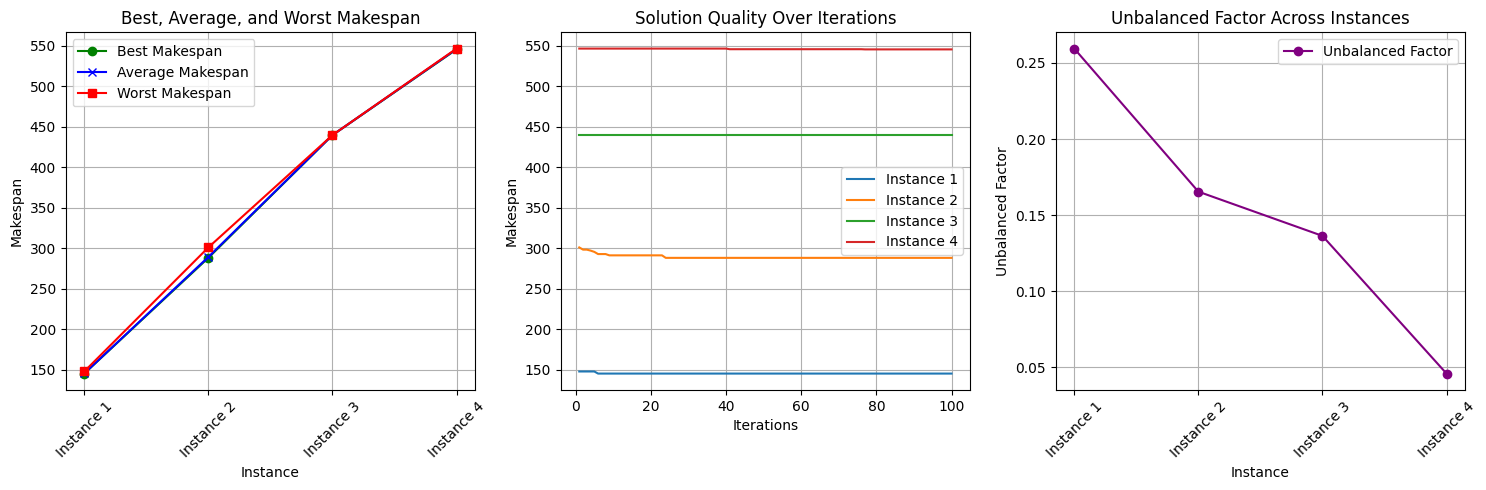

<ipython-input-5-d5b5252b6a9d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


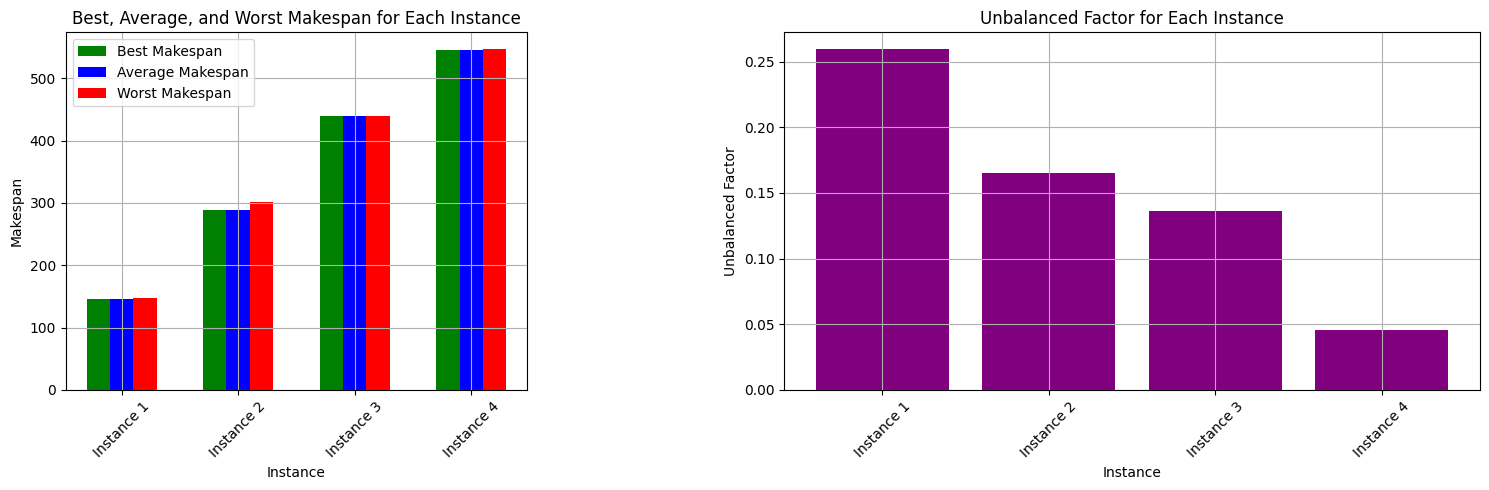

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("AS", filename)
plot_instance_results(results)

Evaluating Instance 1
Instance 1: Best Makespan = 189.09999999999997, Average Makespan = 189.52, Worst Makespan = 231.03, Unbalanced Factor = 4.4817
Evaluating Instance 2
Instance 2: Best Makespan = 427.05000000000007, Average Makespan = 427.05, Worst Makespan = 427.05000000000007, Unbalanced Factor = 4.5557
Evaluating Instance 3
Instance 3: Best Makespan = 563.25, Average Makespan = 563.25, Worst Makespan = 563.25, Unbalanced Factor = 4.3102
Evaluating Instance 4
Instance 4: Best Makespan = 705.9600000000002, Average Makespan = 705.96, Worst Makespan = 705.9600000000002, Unbalanced Factor = 4.5267


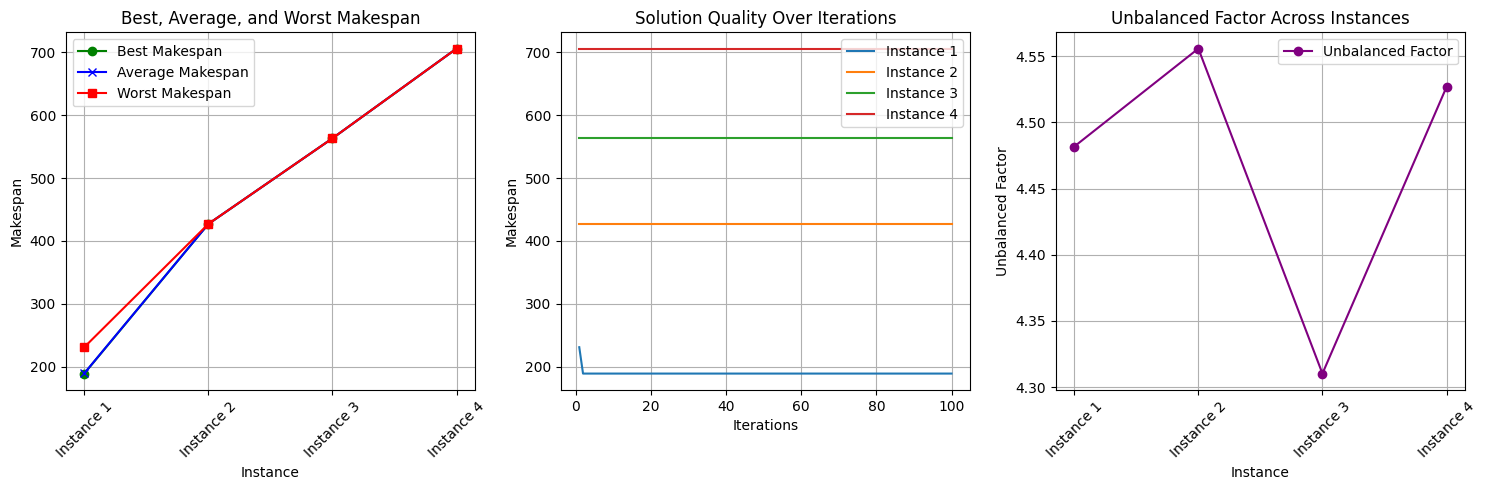

<ipython-input-5-d5b5252b6a9d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


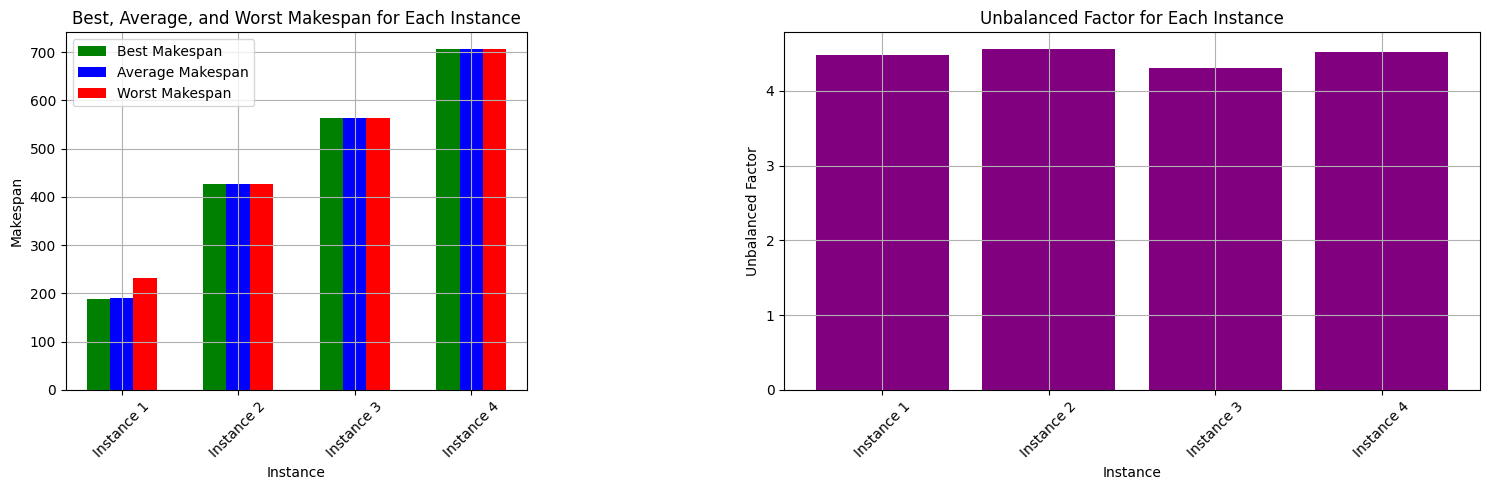

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("OAS", filename)
plot_instance_results(results)

Evaluating Instance 1
Instance 1: Best Makespan = 144.07, Average Makespan = 147.08, Worst Makespan = 152.82000000000002, Unbalanced Factor = 0.3506
Evaluating Instance 2
Instance 2: Best Makespan = 291.16999999999996, Average Makespan = 291.55, Worst Makespan = 294.40000000000003, Unbalanced Factor = 0.2532
Evaluating Instance 3
Instance 3: Best Makespan = 442.12999999999994, Average Makespan = 445.10, Worst Makespan = 470.78999999999996, Unbalanced Factor = 0.1536
Evaluating Instance 4
Instance 4: Best Makespan = 546.9399999999999, Average Makespan = 546.95, Worst Makespan = 548.13, Unbalanced Factor = 0.0974


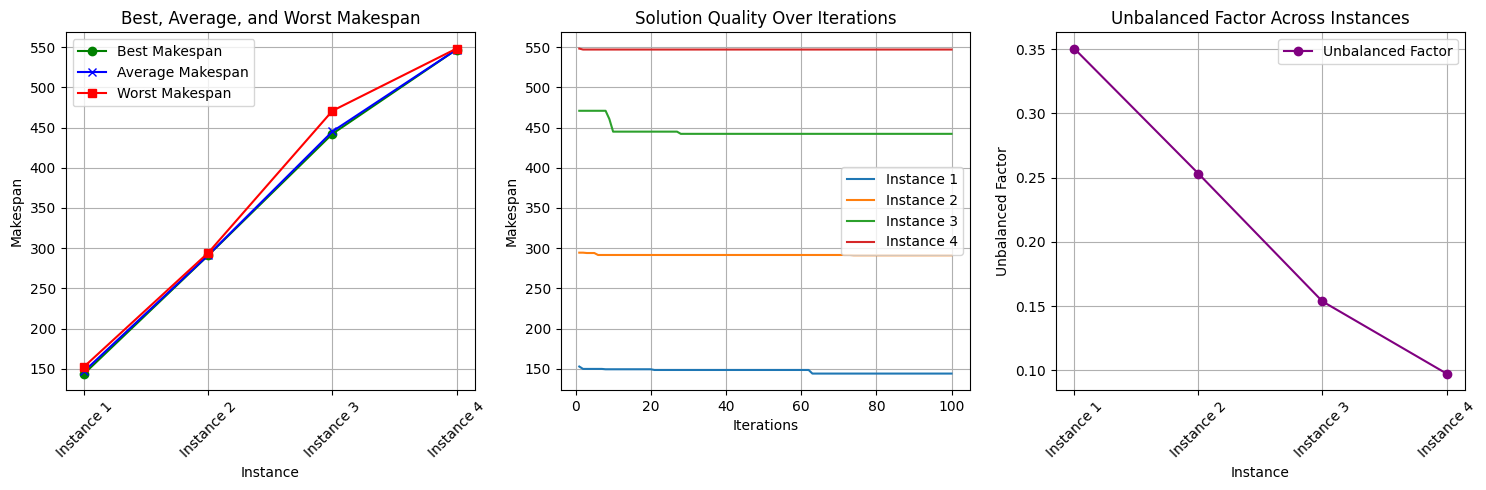

<ipython-input-5-d5b5252b6a9d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


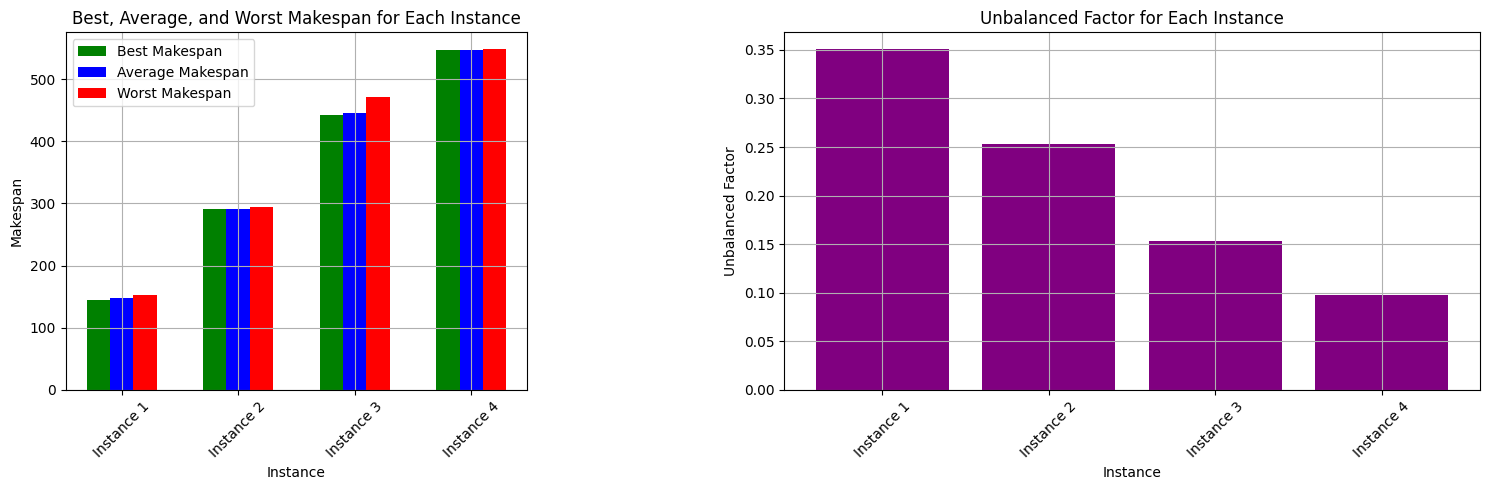

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("ACO", filename)
plot_instance_results(results)

Evaluating Instance 1
Instance 1: Best Makespan = 193.29999999999998, Average Makespan = 193.30, Worst Makespan = 193.29999999999998, Unbalanced Factor = 2.6166
Evaluating Instance 2
Instance 2: Best Makespan = 408.9100000000001, Average Makespan = 408.91, Worst Makespan = 408.9100000000001, Unbalanced Factor = 2.6669
Evaluating Instance 3
Instance 3: Best Makespan = 535.2100000000002, Average Makespan = 535.21, Worst Makespan = 535.2100000000002, Unbalanced Factor = 2.6895
Evaluating Instance 4
Instance 4: Best Makespan = 712.0600000000002, Average Makespan = 712.06, Worst Makespan = 712.0600000000002, Unbalanced Factor = 2.7309


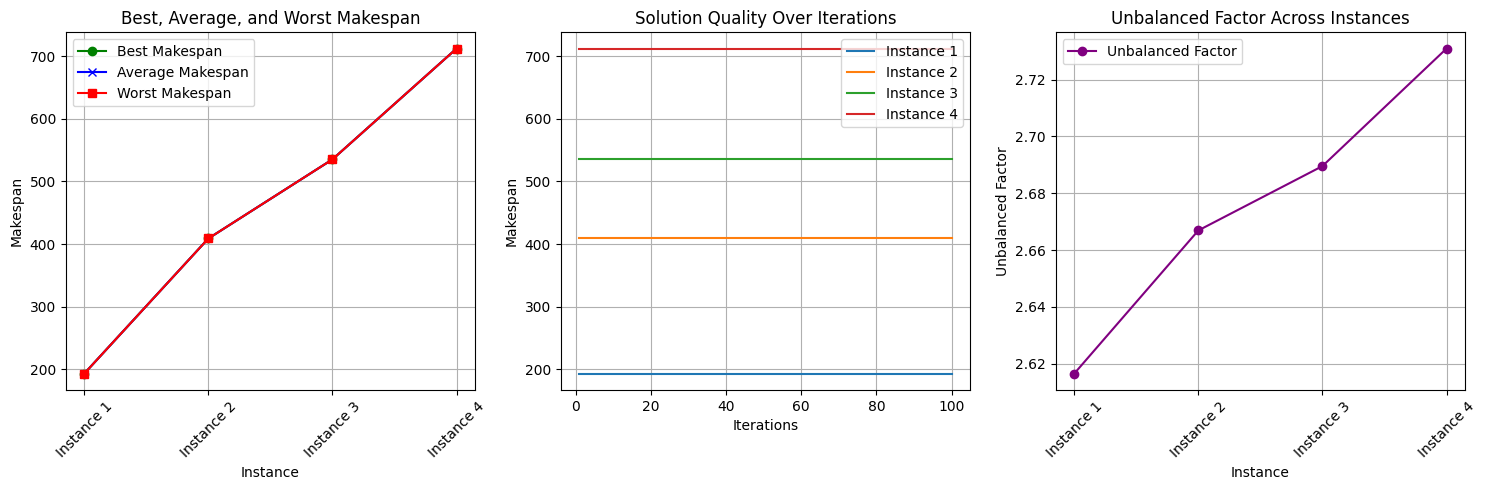

<ipython-input-5-d5b5252b6a9d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


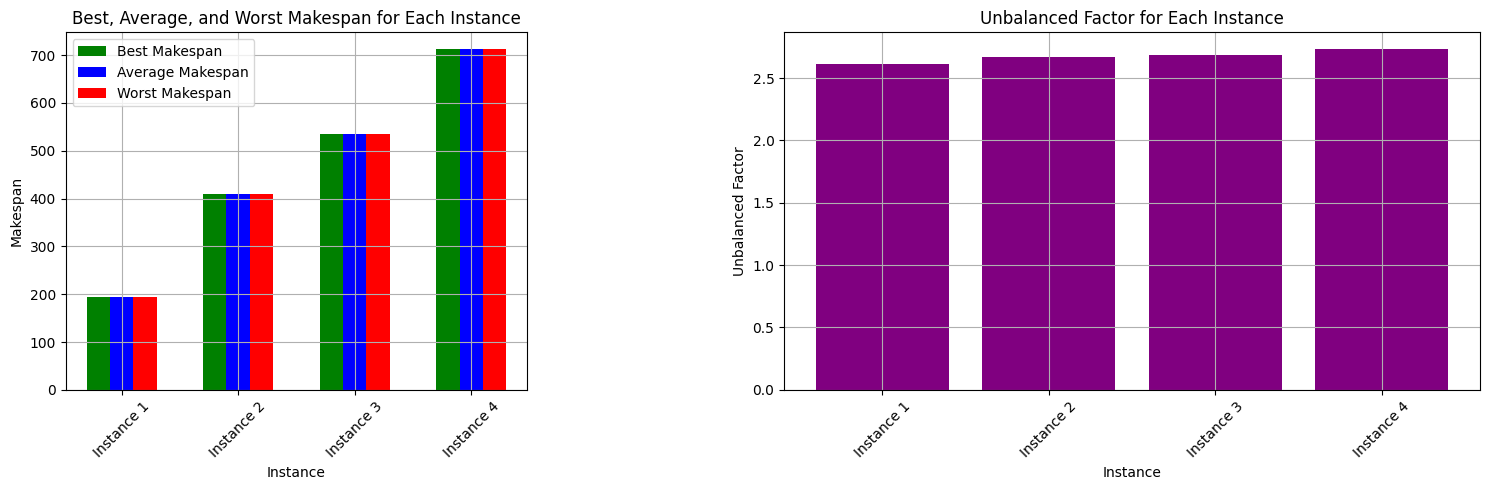

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("OACO", filename)
plot_instance_results(results)

Evaluating Instance 1
Instance 1: Best Makespan = 143.97000000000003, Average Makespan = 145.12, Worst Makespan = 154.89999999999998, Unbalanced Factor = 0.1698
Evaluating Instance 2
Instance 2: Best Makespan = 287.88, Average Makespan = 288.49, Worst Makespan = 296.82, Unbalanced Factor = 0.0954
Evaluating Instance 3
Instance 3: Best Makespan = 438.8299999999999, Average Makespan = 438.96, Worst Makespan = 439.33, Unbalanced Factor = 0.0906
Evaluating Instance 4
Instance 4: Best Makespan = 545.8, Average Makespan = 546.10, Worst Makespan = 548.13, Unbalanced Factor = 0.0561


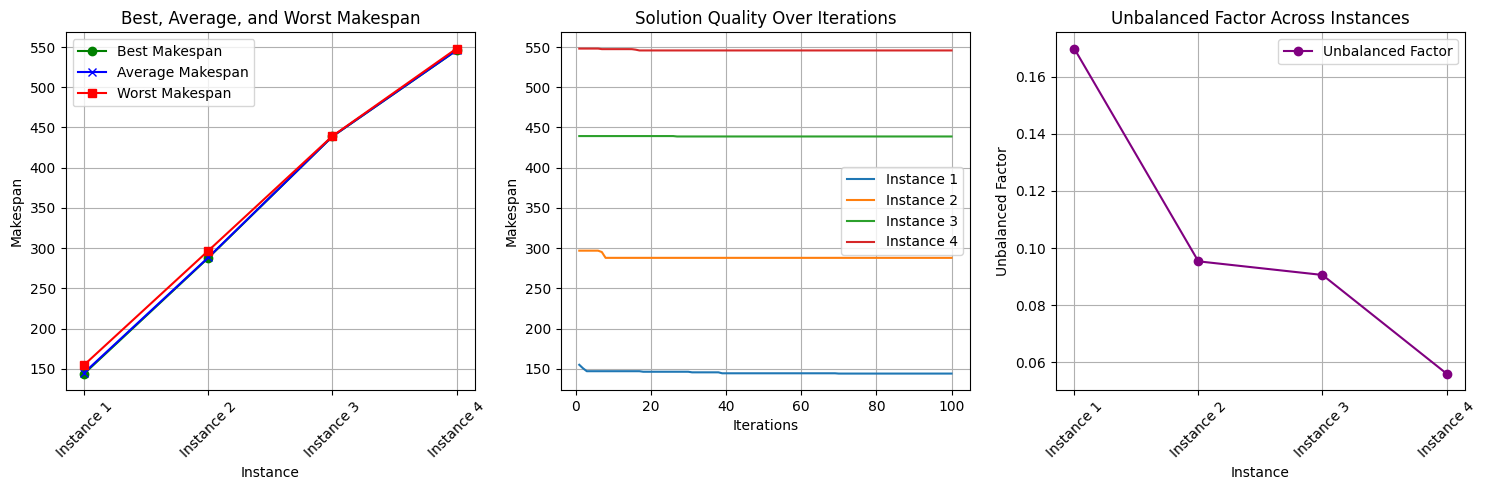

<ipython-input-5-d5b5252b6a9d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


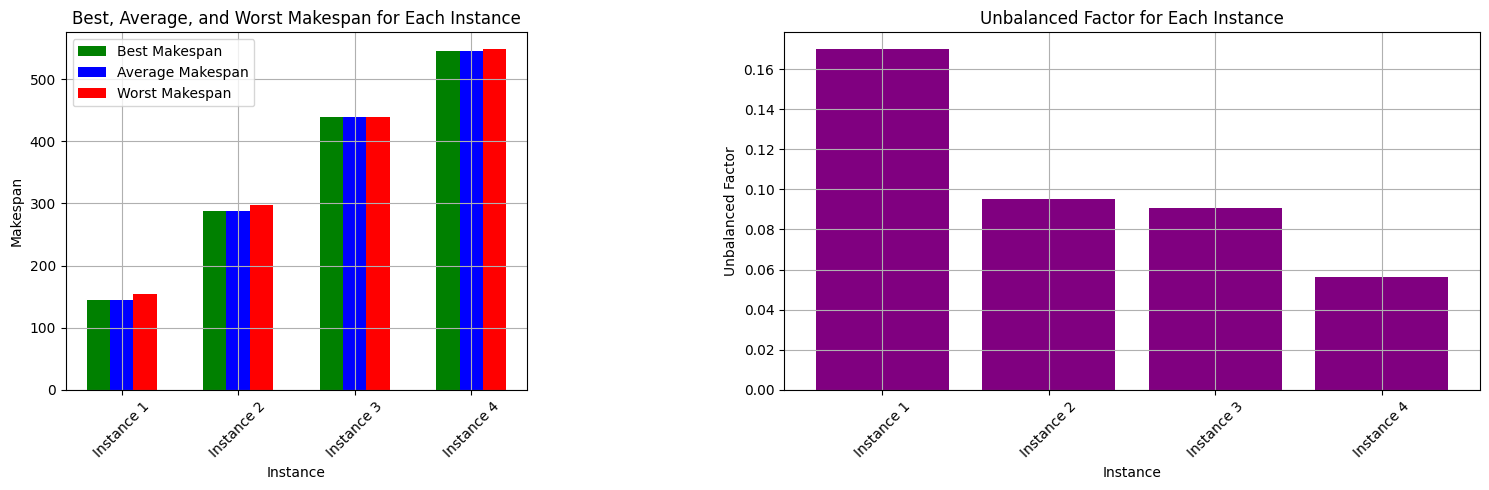

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("MMAS", filename)
plot_instance_results(results)

Evaluating Instance 1
Instance 1: Best Makespan = 180.49999999999997, Average Makespan = 190.27, Worst Makespan = 224.9, Unbalanced Factor = 1.4810
Evaluating Instance 2
Instance 2: Best Makespan = 322.39, Average Makespan = 334.26, Worst Makespan = 415.19, Unbalanced Factor = 0.8849
Evaluating Instance 3
Instance 3: Best Makespan = 519.23, Average Makespan = 540.18, Worst Makespan = 575.8799999999999, Unbalanced Factor = 1.1016
Evaluating Instance 4
Instance 4: Best Makespan = 674.6299999999999, Average Makespan = 677.99, Worst Makespan = 749.56, Unbalanced Factor = 1.0614


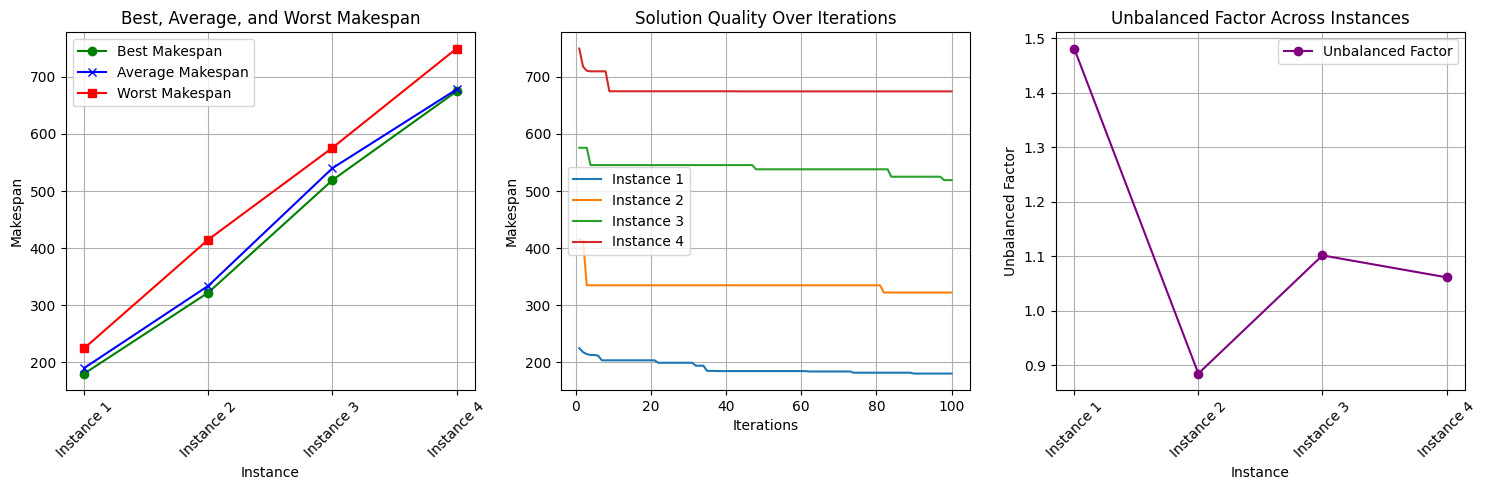

<ipython-input-5-d5b5252b6a9d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


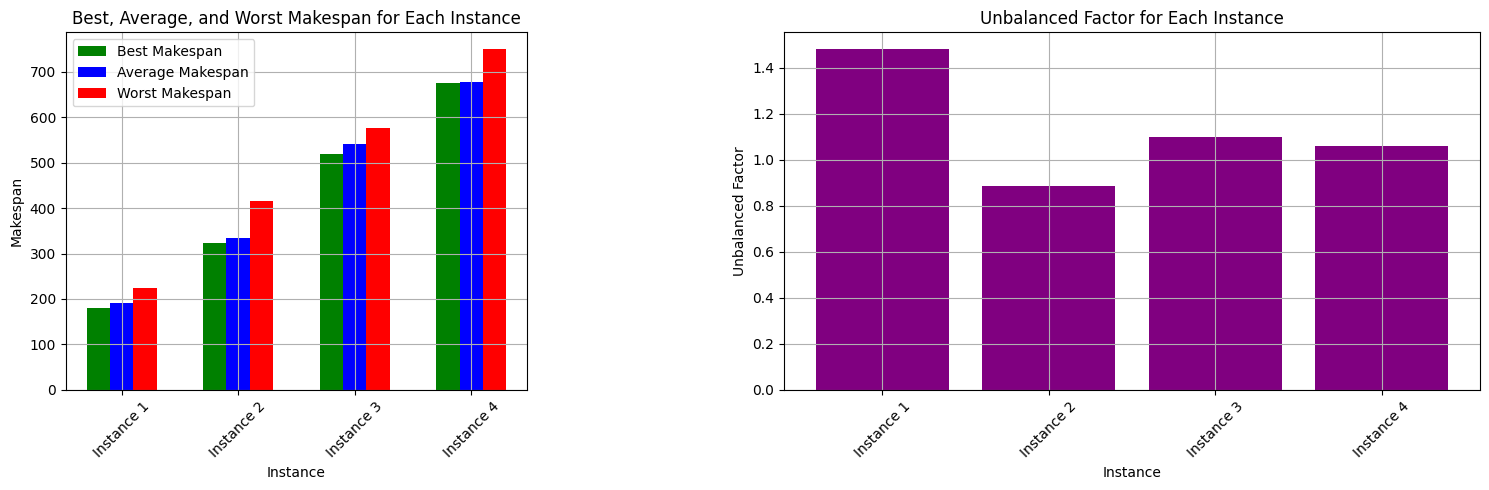

In [ ]:
filename = "gocj_instances.txt"  # File containing all instances
results = evaluate_instances_from_file("OMMAS", filename)
plot_instance_results(results)

# Draft

In [ ]:
# Function for Ant System Optimization to solve the scheduling problem
def as_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                    load_balance = (1 / (vm_loads[vm] + 1)) ** gamma  # Load Balancing Influence
                    probability = pheromone * heuristic * load_balance
                    probabilities.append(probability)

                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                chosen_vm = random.choices(vms, probabilities)[0]
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
          # uf = (max_load - min_load) / max_load if max_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Pheromone update
        pheromone_matrix *= (1 - rho)
        for i, solution in enumerate(all_solutions):
            pheromone_deposit = Q / (all_makespans[i] * (1 + all_ufs[i]))  # Adjust pheromone by UF
            for task, vm in solution:
                pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors

Last update with Tournament Selection

In [ ]:
import random

# Function for Ant System Optimization to solve the scheduling problem
def as_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    # Calculate the new makespan if task is assigned to this VM
                    new_load = vm_loads[vm] + time_matrix[task-1, vm_idx]
                    new_makespan = max(max(vm_loads.values()), new_load)

                    # Dependent-problem heuristic: η_ij = 1 / makespan(i, j)
                    heuristic = 1 / new_makespan

                    # Pheromone and heuristic influence
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    probability = pheromone * (heuristic ** beta)
                    probabilities.append(probability)

                # Normalize probabilities
                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                # Tournament selection strategy
                k = random.randint(1, len(vms))  # Randomly choose k between 1 and number of machines
                pool = []
                for vm_idx, vm in enumerate(vms):
                    if random.random() < 0.5:  # 50% chance to add to pool
                        pool.append((vm, probabilities[vm_idx]))
                    if len(pool) >= k:
                        break

                # Select the machine with the highest probability in the pool
                if pool:
                    chosen_vm = max(pool, key=lambda x: x[1])[0]
                else:
                    chosen_vm = random.choices(vms, probabilities)[0]

                # Assign task to the chosen VM
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Pheromone update
        pheromone_matrix *= (1 - rho)
        for i, solution in enumerate(all_solutions):
            pheromone_deposit = Q / (all_makespans[i] * (1 + all_ufs[i]))  # Adjust pheromone by UF
            for task, vm in solution:
                pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors

Roulette Wheel

In [ ]:
import random

# Function for Ant System Optimization to solve the scheduling problem
def as_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                    load_balance = (1 / (vm_loads[vm] + 1)) ** gamma  # Load Balancing Influence
                    probability = pheromone * heuristic * load_balance
                    probabilities.append(probability)

                # Normalize probabilities
                total = sum(probabilities)
                probabilities = [prob / 1 for prob in probabilities]

                # Roulette Wheel Selection
                r = random.random()  # Random number between 0 and 1
                cumulative_probability = 0
                chosen_vm = None

                for vm_idx, vm in enumerate(vms):
                    cumulative_probability += probabilities[vm_idx]
                    if r <= cumulative_probability:
                        chosen_vm = vm
                        break

                # Assign task to the chosen VM
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Pheromone update
        pheromone_matrix *= (1 - rho)
        for i, solution in enumerate(all_solutions):
            pheromone_deposit = Q / (all_makespans[i] * (1 + all_ufs[i]))  # Adjust pheromone by UF
            for task, vm in solution:
                pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors

Roulette Wheel Selection without normalization

In [ ]:
import random

# Function for Ant System Optimization to solve the scheduling problem
def as_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                scores = []
                for vm_idx, vm in enumerate(vms):
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                    load_balance = (1 / (vm_loads[vm] + 1)) ** gamma  # Load Balancing Influence
                    score = pheromone * heuristic * load_balance
                    scores.append(score)

                # Roulette Wheel Selection without normalization
                total_score = sum(scores)  # Total sum of scores
                r = random.uniform(0, total_score)  # Random number between 0 and total_score
                cumulative_score = 0
                chosen_vm = None

                for vm_idx, vm in enumerate(vms):
                    cumulative_score += scores[vm_idx]
                    if r <= cumulative_score:
                        chosen_vm = vm
                        break

                # Assign task to the chosen VM
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Pheromone update
        pheromone_matrix *= (1 - rho)
        for i, solution in enumerate(all_solutions):
            pheromone_deposit = Q / (all_makespans[i] * (1 + all_ufs[i]))  # Adjust pheromone by UF
            for task, vm in solution:
                pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors

In [ ]:
import random

# Function for Ant System Optimization to solve the scheduling problem
def as_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each standard ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                scores = []
                for vm_idx, vm in enumerate(vms):
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                    load_balance = (1 / (vm_loads[vm] + 1)) ** gamma  # Load Balancing Influence
                    score = pheromone * heuristic * load_balance
                    scores.append(score)

                # Roulette Wheel Selection without normalization
                total_score = sum(scores)  # Total sum of scores
                r = random.uniform(0, total_score)  # Random number between 0 and total_score
                cumulative_score = 0
                chosen_vm = None

                for vm_idx, vm in enumerate(vms):
                    cumulative_score += scores[vm_idx]
                    if r <= cumulative_score:
                        chosen_vm = vm
                        break

                # Assign task to the chosen VM
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Virtual Ant: Construct a solution using a deterministic rule
        virtual_solution = []
        vm_loads_virtual = {vm: 0 for vm in vms}  # Load for each VM

        for task in tasks:
            best_vm = None
            best_score = -1

            # Assign task to the VM with the highest combined pheromone and heuristic value
            for vm_idx, vm in enumerate(vms):
                pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                load_balance = (1 / (vm_loads_virtual[vm] + 1)) ** gamma  # Load Balancing Influence
                score = pheromone * heuristic * load_balance

                if score > best_score:
                    best_score = score
                    best_vm = vm

            # Assign task to the best VM
            task_time = time_matrix[task-1, vms.index(best_vm)]
            vm_loads_virtual[best_vm] += task_time
            virtual_solution.append((task, best_vm))

        # Calculate Makespan for the virtual ant
        virtual_makespan = max(vm_loads_virtual.values())

        # Calculate Unbalanced Factor (UF) for the virtual ant
        min_load_virtual = min(vm_loads_virtual.values())
        max_load_virtual = max(vm_loads_virtual.values())
        avg_load_virtual = sum(vm_loads_virtual.values()) / len(vm_loads_virtual)
        virtual_uf = (max_load_virtual - min_load_virtual) / avg_load_virtual if avg_load_virtual > 0 else 0

        # Update best solution if the virtual ant finds a better one
        if virtual_makespan < best_makespan:
            best_solution = virtual_solution
            best_makespan = virtual_makespan

        # Pheromone update (include the virtual ant's solution)
        pheromone_matrix *= (1 - rho)
        for i, solution in enumerate(all_solutions):
            pheromone_deposit = Q / (all_makespans[i] * (1 + all_ufs[i]))  # Adjust pheromone by UF
            for task, vm in solution:
                pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Update pheromone for the virtual ant's solution
        virtual_pheromone_deposit = Q / (virtual_makespan * (1 + virtual_uf))
        for task, vm in virtual_solution:
            pheromone_matrix[task-1, vms.index(vm)] += virtual_pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs + [virtual_uf]))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors

In [ ]:
import matplotlib.pyplot as plt

# Function for Ant System Optimization to solve the scheduling problem
def as_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    virtual_ant_quality = []  # Store Virtual Ant's Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each standard ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                scores = []
                for vm_idx, vm in enumerate(vms):
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                    load_balance = (1 / (vm_loads[vm] + 1)) ** gamma  # Load Balancing Influence
                    score = pheromone * heuristic * load_balance
                    scores.append(score)

                # Roulette Wheel Selection without normalization
                total_score = sum(scores)  # Total sum of scores
                r = random.uniform(0, total_score)  # Random number between 0 and total_score
                cumulative_score = 0
                chosen_vm = None

                for vm_idx, vm in enumerate(vms):
                    cumulative_score += scores[vm_idx]
                    if r <= cumulative_score:
                        chosen_vm = vm
                        break

                # Assign task to the chosen VM
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Virtual Ant: Construct a solution using a deterministic rule
        virtual_solution = []
        vm_loads_virtual = {vm: 0 for vm in vms}  # Load for each VM

        for task in tasks:
            best_vm = None
            best_score = -1

            # Assign task to the VM with the highest combined pheromone and heuristic value
            for vm_idx, vm in enumerate(vms):
                pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                load_balance = (1 / (vm_loads_virtual[vm] + 1)) ** gamma  # Load Balancing Influence
                score = pheromone * heuristic * load_balance

                if score > best_score:
                    best_score = score
                    best_vm = vm

            # Assign task to the best VM
            task_time = time_matrix[task-1, vms.index(best_vm)]
            vm_loads_virtual[best_vm] += task_time
            virtual_solution.append((task, best_vm))

        # Calculate Makespan for the virtual ant
        virtual_makespan = max(vm_loads_virtual.values())
        virtual_ant_quality.append(virtual_makespan)  # Store Virtual Ant's Makespan

        # Calculate Unbalanced Factor (UF) for the virtual ant
        min_load_virtual = min(vm_loads_virtual.values())
        max_load_virtual = max(vm_loads_virtual.values())
        avg_load_virtual = sum(vm_loads_virtual.values()) / len(vm_loads_virtual)
        virtual_uf = (max_load_virtual - min_load_virtual) / avg_load_virtual if avg_load_virtual > 0 else 0

        # Update best solution if the virtual ant finds a better one
        if virtual_makespan < best_makespan:
            best_solution = virtual_solution
            best_makespan = virtual_makespan

        # Pheromone update (include the virtual ant's solution)
        pheromone_matrix *= (1 - rho)
        for i, solution in enumerate(all_solutions):
            pheromone_deposit = Q / (all_makespans[i] * (1 + all_ufs[i]))  # Adjust pheromone by UF
            for task, vm in solution:
                pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Update pheromone for the virtual ant's solution
        virtual_pheromone_deposit = Q / (virtual_makespan * (1 + virtual_uf))
        for task, vm in virtual_solution:
            pheromone_matrix[task-1, vms.index(vm)] += virtual_pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs + [virtual_uf]))  # Minimum UF for each iteration

    # Plot the comparison between Virtual Ant and Best Solution
    plt.figure(figsize=(10, 6))
    plt.plot(range(n_iterations), solution_quality, label="Best Solution", marker="o")
    plt.plot(range(n_iterations), virtual_ant_quality, label="Virtual Ant", marker="x")
    plt.xlabel("Iteration")
    plt.ylabel("Makespan")
    plt.title("Comparison of Virtual Ant and Best Solution")
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_solution, best_makespan, solution_quality, unbalanced_factors

ACO

In [ ]:
# Function for Ant Colony Optimization
def aco_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                    load_balance = (1 / (vm_loads[vm] + 1)) ** gamma  # Load Balancing Influence
                    probability = pheromone * heuristic * load_balance
                    probabilities.append(probability)

                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                chosen_vm = random.choices(vms, probabilities)[0]
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

                # Local Update: Update pheromone for the chosen task-VM pair
                pheromone_matrix[task-1, vms.index(chosen_vm)] = (1 - rho) * pheromone_matrix[task-1, vms.index(chosen_vm)] + (rho * Q / task_time)

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Global Update: Only the best ant updates the pheromone matrix
        pheromone_matrix *= (1 - rho)
        for task, vm in best_solution:
            pheromone_deposit = Q / best_makespan
            pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors


**Min-Max Ant System**

In [ ]:
# Function for Min-Max Ant System (MMAS)
def mmas_schedule(tasks, vms, time_matrix, pheromone_matrix, heuristic_matrix):
    best_solution = None
    best_makespan = float('inf')
    solution_quality = []  # Store Makespan for each iteration
    unbalanced_factors = []  # List to store UF for each iteration

    for iteration in range(n_iterations):
        all_solutions = []
        all_makespans = []
        all_ufs = []  # Store UF for each solution

        # Create solutions for each ant
        for ant in range(n_ants):
            solution = []
            vm_loads = {vm: 0 for vm in vms}  # Load for each VM

            # Build the solution by assigning tasks to VMs
            for task in tasks:
                probabilities = []
                for vm_idx, vm in enumerate(vms):
                    pheromone = pheromone_matrix[task-1, vm_idx] ** alpha
                    heuristic = heuristic_matrix[task-1, vm_idx] ** beta
                    load_balance = (1 / (vm_loads[vm] + 1)) ** gamma  # Load Balancing Influence
                    probability = pheromone * heuristic * load_balance
                    probabilities.append(probability)

                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                chosen_vm = random.choices(vms, probabilities)[0]
                task_time = time_matrix[task-1, vms.index(chosen_vm)]
                vm_loads[chosen_vm] += task_time
                solution.append((task, chosen_vm))

            # Calculate Makespan
            makespan = max(vm_loads.values())
            all_solutions.append(solution)
            all_makespans.append(makespan)

            # Calculate Unbalanced Factor (UF)
            min_load = min(vm_loads.values())
            max_load = max(vm_loads.values())
            avg_load = sum(vm_loads.values()) / len(vm_loads)
            uf = (max_load - min_load) / avg_load if avg_load > 0 else 0
            all_ufs.append(uf)

            # Update best solution
            if makespan < best_makespan:
                best_solution = solution
                best_makespan = makespan

        # Pheromone update (Global Best Only)
        pheromone_matrix *= (1 - rho)
        pheromone_deposit = Q / best_makespan
        for task, vm in best_solution:
            pheromone_matrix[task-1, vms.index(vm)] += pheromone_deposit

        # Apply Min-Max limits to pheromone values
        pheromone_matrix = np.clip(pheromone_matrix, tau_min, tau_max)

        # Store Best Makespan and UF for each iteration
        solution_quality.append(best_makespan)
        unbalanced_factors.append(min(all_ufs))  # Minimum UF for each iteration

    return best_solution, best_makespan, solution_quality, unbalanced_factors


In [ ]:
# Function to plot results for multiple instances
def plot_instance_results(results):
    """
    Plots the results for multiple instances:
    1. Grouped bar plot for Best, Average, and Worst Makespan.
    2. Line plot for Solution Quality (makespan over iterations).
    3. Bar plot for Unbalanced Factor.
    4. Line plot for Solution Quality (makespan over iterations) for each instance.
    5. Line plot for Unbalanced Factor over iterations.
    """
    instance_names = [result['instance'] for result in results]
    best_makespans = [result['best_makespan'] for result in results]
    average_makespans = [result['average_makespan'] for result in results]
    worst_makespans = [result['worst_makespan'] for result in results]
    unbalanced_factors = [result['unbalanced_factor'] for result in results]
    solution_qualities = [result['solution_quality'] for result in results]


    plt.figure(figsize=(15, 5))

    # Plot 1: Best, Average, and Worst Makespan
    plt.subplot(1, 3, 1)
    plt.plot(instance_names, best_makespans, label="Best Makespan", marker="o", color="green")
    plt.plot(instance_names, average_makespans, label="Average Makespan", marker="x", color="blue")
    plt.plot(instance_names, worst_makespans, label="Worst Makespan", marker="s", color="red")
    plt.xlabel("Instance")
    plt.ylabel("Makespan")
    plt.title("Best, Average, and Worst Makespan")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    # Plot 2: Solution Quality (Makespan over iterations)
    plt.subplot(1, 3, 2)
    for i, solution_quality in enumerate(solution_qualities):
        plt.plot(range(1, len(solution_quality) + 1), solution_quality, label=f"Instance {i + 1}")
    plt.xlabel("Iterations")
    plt.ylabel("Makespan")
    plt.title("Solution Quality Over Iterations")
    plt.legend()
    plt.grid(True)

    # Plot 3: Unbalanced Factor
    plt.subplot(1, 3, 3)
    plt.plot(instance_names, unbalanced_factors, label="Unbalanced Factor", marker="o", color="purple")
    plt.xlabel("Instance")
    plt.ylabel("Unbalanced Factor")
    plt.title("Unbalanced Factor Across Instances")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(15, 5))

    # Plot 1: Grouped bar plot for Best, Average, and Worst Makespan

    x = np.arange(len(instance_names))  # the label locations
    width = 0.2  # the width of the bars
    plt.subplot(1, 3, 1)
    plt.bar(x - width, best_makespans, width, label='Best Makespan', color='green')
    plt.bar(x, average_makespans, width, label='Average Makespan', color='blue')
    plt.bar(x + width, worst_makespans, width, label='Worst Makespan', color='red')

    plt.xlabel('Instance')
    plt.ylabel('Makespan')
    plt.title('Best, Average, and Worst Makespan for Each Instance')
    plt.xticks(x, instance_names, rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()


    # Plot 2: Bar plot for Unbalanced Factor
    plt.subplot(1, 2, 2)
    plt.bar(instance_names, unbalanced_factors, color='purple')
    plt.xlabel('Instance')
    plt.ylabel('Unbalanced Factor')
    plt.title('Unbalanced Factor for Each Instance')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()


    plt.show()




evaluate instances using AS, ACO, MMAS methods

In [ ]:
# Function to evaluate
def evaluate_instances_from_file(system_name, filename):
    """
     multiple instances
    """
    instances = load_instances_from_file(filename)
    results = []

    for idx, instance in enumerate(instances):
        print(f"Evaluating Instance {idx + 1}")
        tasks = instance['tasks']
        machines = instance['machines']
        time_matrix = np.array(instance['time_matrix'])

        # Initialize pheromones and heuristic matrix
        pheromone_matrix = initialize_pheromones(tasks, machines)
        heuristic_matrix = 1 / (time_matrix + 1e-10)

        # Run ACO for the current instance
        if system_name == "AS":
            best_solution, best_makespan, solution_quality, uf = as_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)
        elif system_name == "ACO":
            best_solution, best_makespan, solution_quality, uf = aco_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)
        elif system_name == "MMAS":
            best_solution, best_makespan, solution_quality, uf = mmas_schedule(tasks, machines, time_matrix, pheromone_matrix, heuristic_matrix)
        else:
            raise ValueError("Invalid system name. Choose 'AS', 'ACO', or 'MMAS'.")

        # Calculate average and worst makespan
        average_makespan = np.mean(solution_quality)
        worst_makespan = np.max(solution_quality)

        # Store results for this instance
        results.append({
            "instance": f"Instance {idx + 1}",
            "best_makespan": best_makespan,
            "average_makespan": average_makespan,
            "worst_makespan": worst_makespan,
            "solution_quality": solution_quality,
            "unbalanced_factor": np.mean(uf)  # Use the mean unbalanced factor
        })

        print(f"Instance {idx + 1}: Best Makespan = {best_makespan}, Average Makespan = {average_makespan:.2f}, Worst Makespan = {worst_makespan}, Unbalanced Factor = {np.mean(uf):.4f}")

    return results




---



**TEST**

AS

Evaluating Instance 1
Instance 1: Best Makespan = 7, Average Makespan = 7.10, Worst Makespan = 9, Unbalanced Factor = 0.3719
Evaluating Instance 2
Instance 2: Best Makespan = 13, Average Makespan = 14.02, Worst Makespan = 19, Unbalanced Factor = 0.5774
Evaluating Instance 3
Instance 3: Best Makespan = 20, Average Makespan = 20.30, Worst Makespan = 26, Unbalanced Factor = 0.6354
Evaluating Instance 4
Instance 4: Best Makespan = 25, Average Makespan = 25.93, Worst Makespan = 33, Unbalanced Factor = 0.4672
Evaluating Instance 5
Instance 5: Best Makespan = 30, Average Makespan = 31.36, Worst Makespan = 42, Unbalanced Factor = 0.3961
Evaluating Instance 6
Instance 6: Best Makespan = 36, Average Makespan = 37.78, Worst Makespan = 47, Unbalanced Factor = 0.3691
Evaluating Instance 7
Instance 7: Best Makespan = 41, Average Makespan = 43.51, Worst Makespan = 54, Unbalanced Factor = 0.3403
Evaluating Instance 8
Instance 8: Best Makespan = 47, Average Makespan = 49.24, Worst Makespan = 64, Unbala

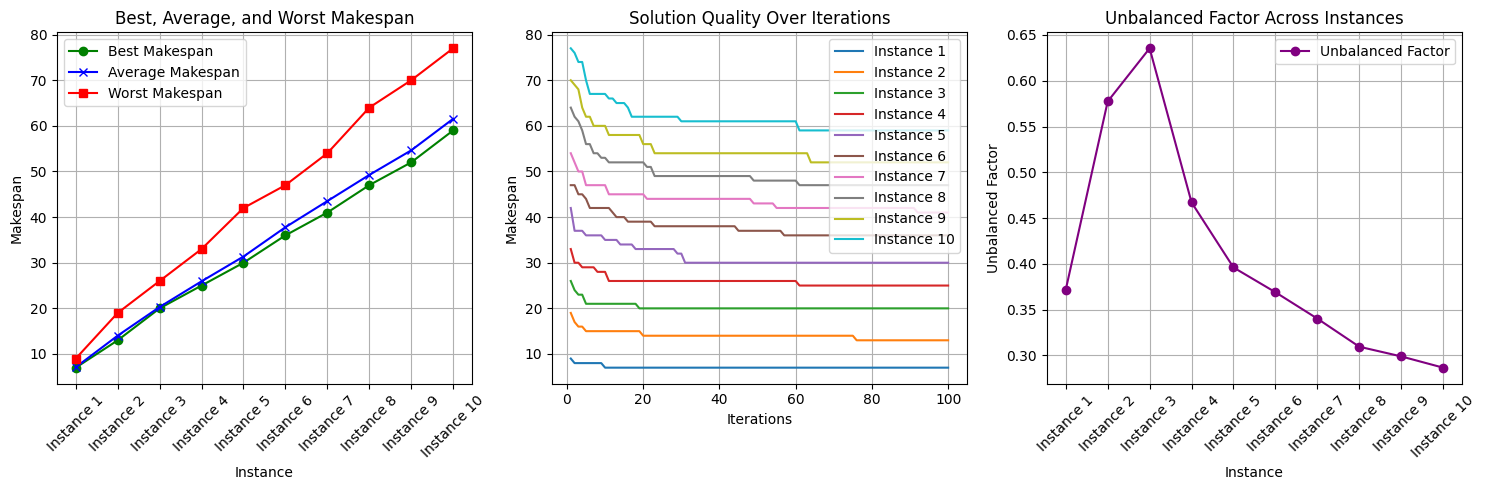

<ipython-input-7-8e5aebdd397d>:85: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


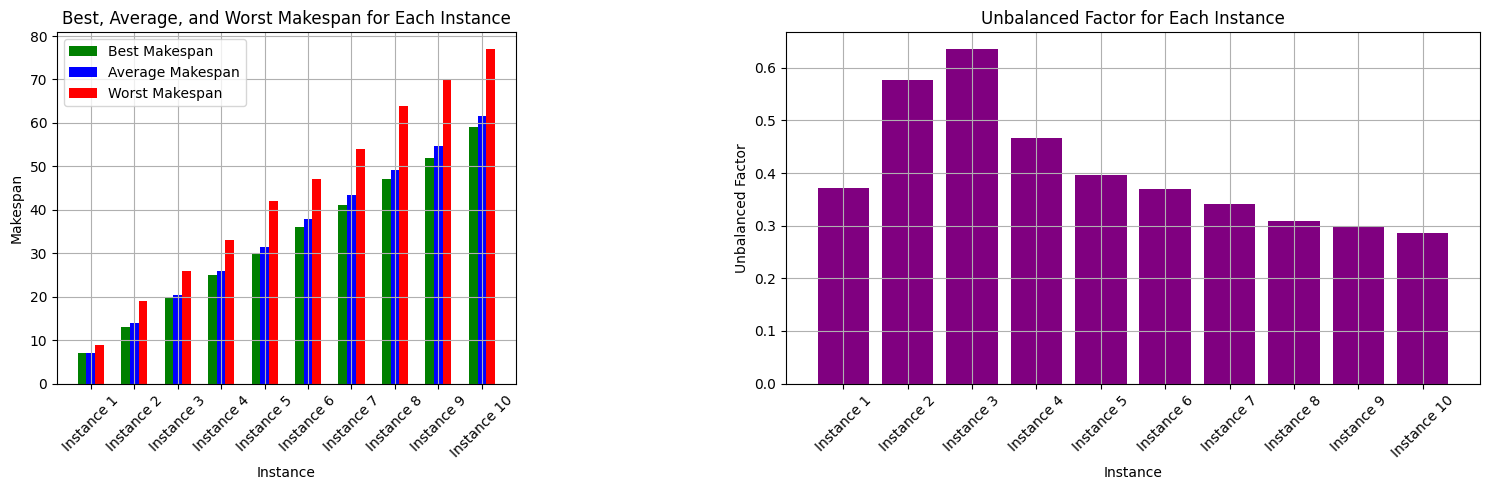

In [ ]:
filename = "instances.txt"  # File containing all instances
results = evaluate_instances_from_file("AS", filename)
plot_instance_results(results)

ACO

Evaluating Instance 1
Instance 1: Best Makespan = 6, Average Makespan = 6.26, Worst Makespan = 8, Unbalanced Factor = 0.2939
Evaluating Instance 2
Instance 2: Best Makespan = 13, Average Makespan = 13.36, Worst Makespan = 16, Unbalanced Factor = 0.6589
Evaluating Instance 3
Instance 3: Best Makespan = 21, Average Makespan = 21.25, Worst Makespan = 27, Unbalanced Factor = 0.5339
Evaluating Instance 4
Instance 4: Best Makespan = 26, Average Makespan = 27.24, Worst Makespan = 30, Unbalanced Factor = 0.4576
Evaluating Instance 5
Instance 5: Best Makespan = 32, Average Makespan = 32.47, Worst Makespan = 40, Unbalanced Factor = 0.4344
Evaluating Instance 6
Instance 6: Best Makespan = 37, Average Makespan = 38.08, Worst Makespan = 47, Unbalanced Factor = 0.3819
Evaluating Instance 7
Instance 7: Best Makespan = 44, Average Makespan = 45.03, Worst Makespan = 54, Unbalanced Factor = 0.3519
Evaluating Instance 8
Instance 8: Best Makespan = 49, Average Makespan = 50.99, Worst Makespan = 60, Unbala

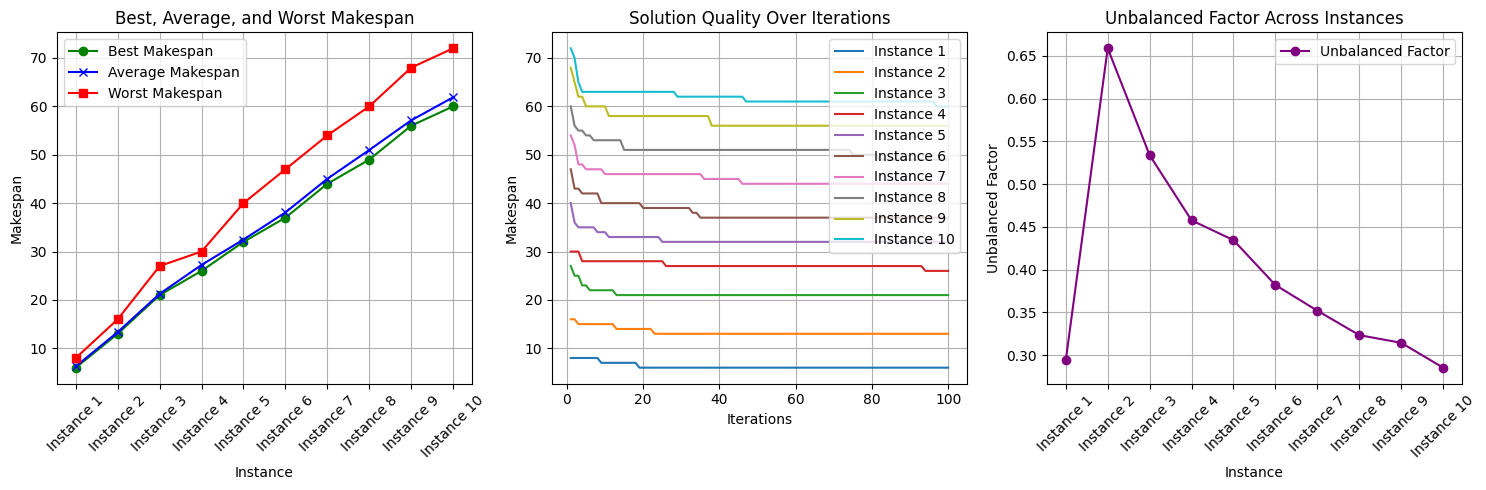

<ipython-input-8-cbca5bff6c6f>:83: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


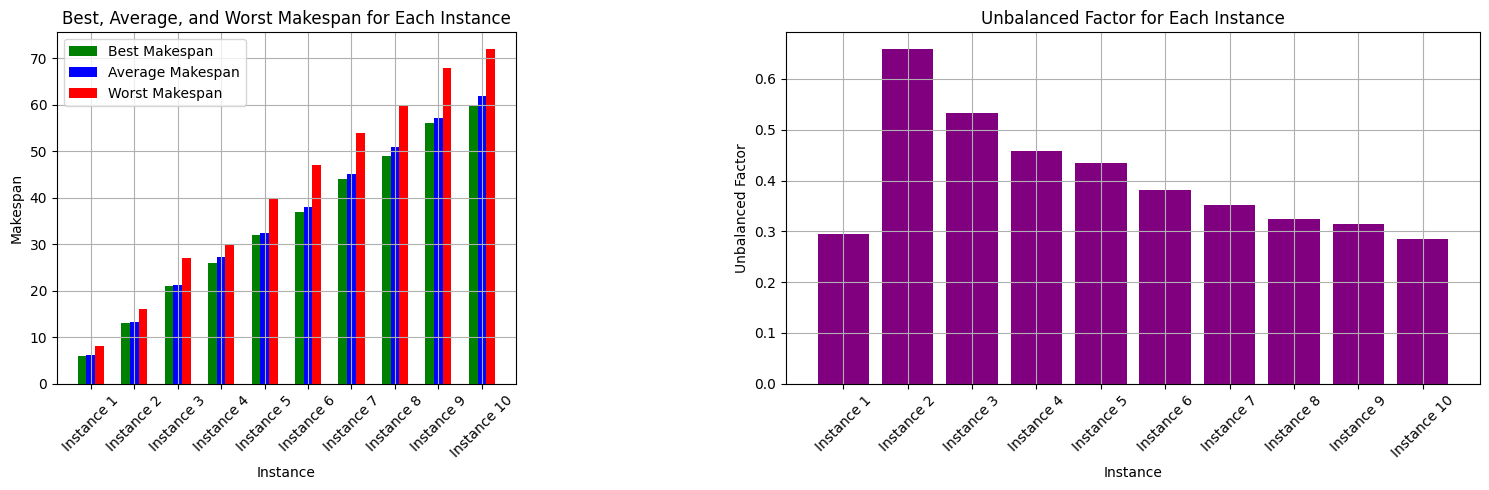

In [ ]:
filename = "instances.txt"  # File containing all instances
results = evaluate_instances_from_file("ACO", filename)
plot_instance_results(results)


MMAS

Evaluating Instance 1
Instance 1: Best Makespan = 7, Average Makespan = 7.13, Worst Makespan = 8, Unbalanced Factor = 0.3403
Evaluating Instance 2
Instance 2: Best Makespan = 13, Average Makespan = 13.30, Worst Makespan = 16, Unbalanced Factor = 0.2891
Evaluating Instance 3
Instance 3: Best Makespan = 22, Average Makespan = 22.25, Worst Makespan = 25, Unbalanced Factor = 0.3037
Evaluating Instance 4
Instance 4: Best Makespan = 28, Average Makespan = 28.87, Worst Makespan = 33, Unbalanced Factor = 0.2950
Evaluating Instance 5
Instance 5: Best Makespan = 32, Average Makespan = 33.80, Worst Makespan = 40, Unbalanced Factor = 0.3905
Evaluating Instance 6
Instance 6: Best Makespan = 41, Average Makespan = 41.17, Worst Makespan = 48, Unbalanced Factor = 0.2622
Evaluating Instance 7
Instance 7: Best Makespan = 46, Average Makespan = 47.94, Worst Makespan = 58, Unbalanced Factor = 0.2977
Evaluating Instance 8
Instance 8: Best Makespan = 54, Average Makespan = 54.77, Worst Makespan = 67, Unbala

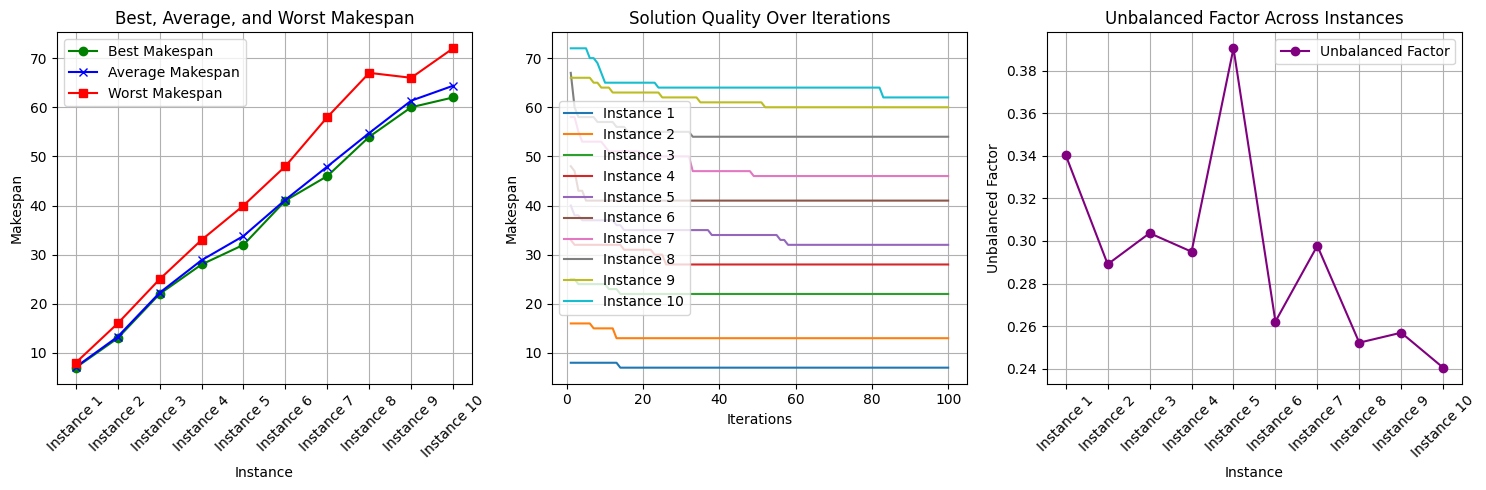

<ipython-input-8-cbca5bff6c6f>:83: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


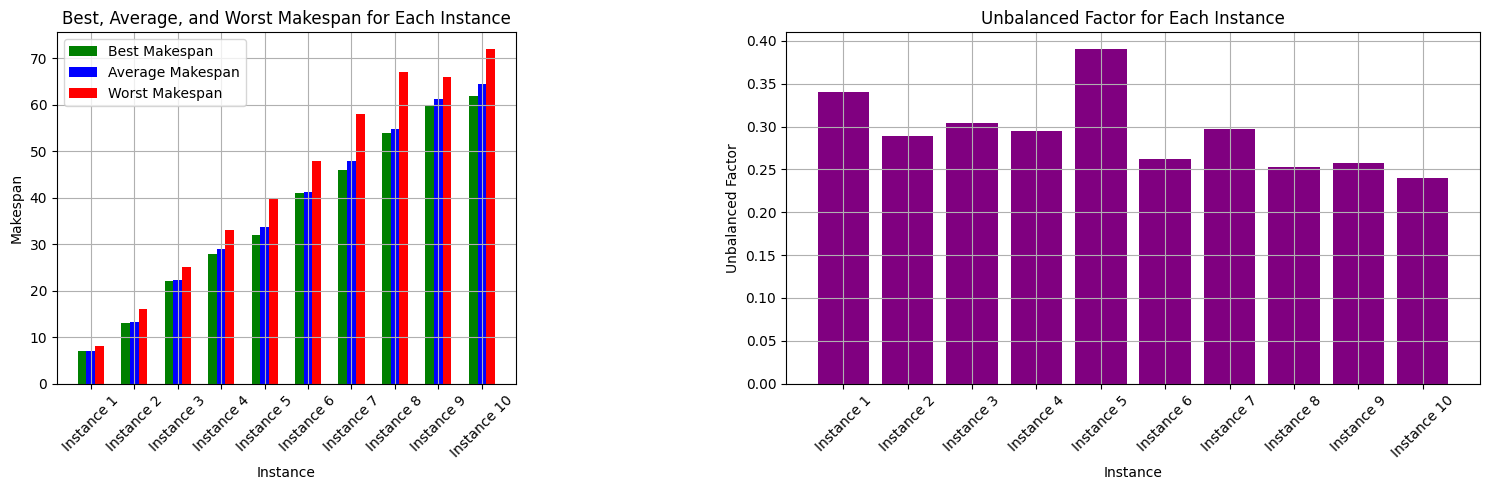

In [ ]:
filename = "instances.txt"  # File containing all instances
results = evaluate_instances_from_file("MMAS", filename)
plot_instance_results(results)